## 0 Contexto

El aprendizaje por refuerzo es un campo de la inteligencia artificial que busca desarrollar sistemas capaces de aprender y tomar decisiones autónomas a través de la interacción con su entorno. A lo largo de los años, este enfoque ha demostrado su eficacia en ámbitos muy diversos, desde juegos clásicos hasta robótica o control de sistemas complejos. Sin embargo, uno de los principales retos del aprendizaje por refuerzo consiste en diseñar entornos de simulación adecuados que representen de forma precisa la dinámica de la tarea que se desea abordar.

En este contexto, esta PEC tiene como objetivo desarrollar un nuevo entorno de simulación denominado **Pong en la pared**, inspirado en el clásico juego Pong, pero modificado para que solo intervenga un jugador. En este entorno, el agente debe controlar una pala que rebota una pelota contra una pared, intentando mantener el juego activo el mayor tiempo posible y evitar que la pelota se escape. De este modo, el entorno permite experimentar con diferentes algoritmos de aprendizaje por refuerzo aplicados a tareas de control continuo, percepción y toma de decisiones en tiempo real.

Para ello, se implementará el entorno siguiendo las especificaciones de Gymnasium (https://gymnasium.farama.org
), que proporciona una interfaz estándar para la creación de entornos personalizados de aprendizaje por refuerzo. El entorno simulará el comportamiento dinámico del juego, incluyendo la física de rebote de la pelota, la velocidad de movimiento y la penalización por perder el control de la pelota, ofreciendo así una plataforma adecuada para entrenar y evaluar agentes inteligentes


## 1 Creación de un entorno en Gym (3 ptos)

En este ejercicio diseñaremos un entorno sencillo siguiendo el esquema de los entornos de <code>Gymnasium</code>, y trataremos de resolverlo.

Los entornos de <code>Gymnasium</code> suelen tener la siguiente estructura:

```
class FooEnv(gym.Env):
  metadata = {'render.modes': ['human']}

  def __init__(self):
    ...
  def step(self, action):
    ...
    return new_state, reward, terminated, truncated, info

  def reset(self):
    ...
    return observation, info

  def render(self, mode='human', close=False):
    ...

 ```


El primer paso será instalar las librerías necesarias para abordar la PEC:


y las importamos:

In [1]:
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt
from gymnasium.spaces import Discrete, Box
from collections import namedtuple, deque
from copy import deepcopy
import math
import time
import torch
import torch.nn.functional as F
from tabulate import tabulate
import pandas as pd
import warnings
from tqdm.auto import tqdm



warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

print("Esta PEC ha sido testeada en Google Colab con las versiones siguientes:")
print("Gym Version:", gym.__version__)
print("Torch Version:", torch.__version__)

Esta PEC ha sido testeada en Google Colab con las versiones siguientes:
Gym Version: 1.2.1
Torch Version: 2.9.1+cpu


C:\Users\Usuario\Desktop\UOC\uocvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



###  1.0 Entorno de Simulación: Pong en la pared (un solo jugador)

<section>
  <h3>Entorno de Simulación: <em>Pong en la pared</em></h3>

  <ul>
    <li><strong>Nombre del entorno (clase):</strong> <code>SimplePongEnv</code> (registrado como <code>SimplePong-v0</code>).</li>
    <li><strong>Base:</strong> hereda de <code>gym.Env</code> y sigue la interfaz Gymnasium (<code>reset</code>, <code>step</code>, <code>render</code>).</li>
    <li><strong>Zona de juego por defecto:</strong> rejilla discreta de <code>width=24</code>, <code>height=18</code>, con bordes sólidos.</li>
  </ul>

  <h4>Pala (jugador)</h4>
  <ul>
    <li>Ubicada en la columna derecha (<code>paddle_col = width - 2</code>).</li>
    <li>Tamaño por defecto <code>paddle_size=4</code>.</li>
    <li>Posición vertical limitada al área jugable.</li>
  </ul>

  <h4>Pelota</h4>
  <ul>
    <li>Se mueve una celda por paso.</li>
    <li>Velocidad horizontal <code>vx ∈ {+1, -1}</code> y vertical <code>vy ∈ {-1, 0, 1}</code> con rebotes en techo/suelo/pared izquierda.</li>
    <li>Al impactar en la pala, se refleja (<code>vx = -1</code>) y se reasigna un <code>vy</code> estable con mayor probabilidad de ±1 que de 0.</li>
  </ul>

  <h4>Espacio de acciones: <code>Discrete(3)</code></h4>
  <ul>
    <li><strong>0</strong> → mover pala <strong>arriba</strong> (–1 celda)</li>
    <li><strong>1</strong> → <strong>mantener</strong> posición</li>
    <li><strong>2</strong> → mover pala <strong>abajo</strong> (+1 celda)</li>
  </ul>

  <h4>Espacio de observación</h4>
  <p><code>Box(low=[0,0,0,-1,-1], high=[1,1,1,1,1], dtype=float32)</code> con 5 características normalizadas:</p>
  <ul>
    <li><code>paddle_y_norm</code> → posición vertical de la pala</li>
    <li><code>ball_x_norm</code> → posición x de la pelota</li>
    <li><code>ball_y_norm</code> → posición y de la pelota</li>
    <li><code>vx_norm</code> → velocidad x de la pelota (en [-1, 1])</li>
    <li><code>vy_norm</code> → velocidad y de la pelota (en [-1, 1])</li>
  </ul>

  <h4>Sistema de recompensas</h4>
  <ul>
    <li><strong>+1.0</strong> al golpear la pelota con la pala (rebote correcto).</li>
    <li><strong>-1.0</strong> si la pelota supera la pala (fallo) ⇒ episodio <em>termina</em>.</li>
    <li><strong>-0.01</strong> de penalización por paso para incentivar eficiencia (evitar “jugar” indefinidamente sin mejorar).</li>
  </ul>

  <h4>Duración del episodio</h4>
  <ul>
    <li>Por defecto <code>max_steps=2000</code> (episodio <em>truncado</em> si se alcanza).</li>
    <li>Termina antes si el agente falla el rebote (condición de <code>terminated=True</code>).</li>
  </ul>

  <h4>Renderizado</h4>
  <p>Modo <code>rgb_array</code> en escala de grises para visualización en Jupyter (campo, pala, pelota y “red” central).</p>

  <h4>Objetivo de aprendizaje</h4>
  <p>Maximizar la recompensa acumulada por episodio, lo que equivale a mantener la pelota en juego el mayor tiempo posible mediante una colocación y seguimiento eficaces de la pala.</p>
</section>



**Nota de implementació (ya presente en tu notebook)**: el entorno se registra como

```python
register(
    id="SimplePong-v0",
    entry_point="__main__:SimplePongEnv"
)
```
y se puede instanciar con:
```python
env = gym.make(
    "SimplePong-v0",
    render_mode="rgb_array",
    width=24,
    height=18,
    paddle_size=4,
    max_steps=2000
)
```

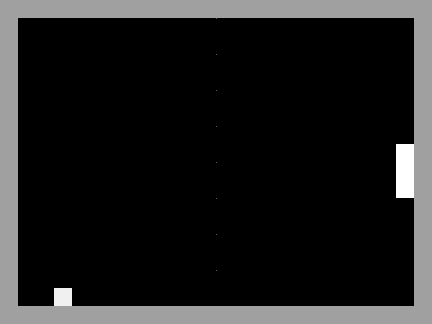

### 1.1 Implementación del entorno SimplePongEnv (Pong en la pared)

  <h4>Checklist de TODOs a completar</h4>
  <ol>
    <li>
      <strong>Espacios de Gymnasium</strong>
      <ul>
        <li>Definir <code>action_space = ....</code>.</li>
        <li>Definir <code>observation_space = spaces.Box(...)</code> con 5 características normalizadas:
          <code>[paddle_y_norm, ball_x_norm, ball_y_norm, vx_norm, vy_norm]</code> y <code>dtype=np.float32</code>.
        </li>
      </ul>
    </li>
    <li>
      <strong>Inicialización del estado (<code>reset_vars</code>)</strong>
      <ul>
        <li>Reiniciar el contador: <code>self.step_count = 0</code>.</li>
        <li>Colocar la pala centrada verticalmente.</li>
        <li>Colocar la pelota cerca de la pared izquierda (<code>ball_x = play_min_x + 1</code>).</li>
        <li>Asignar <code>ball_y</code> aleatorio dentro del área jugable.</li>
        <li>Fijar <code>vx = +1</code> (hacia la pala).</li>
        <li>Elegir <code>vy ∈ {-1, 0, 1}</code> aleatorio.</li>
      </ul>
    </li>
    <li>
      <strong>Reinicio del entorno (<code>reset</code>)</strong>
      <ul>
        <li>Si llega <code>seed</code>, re-inicializar el RNG: <code>self.rng = np.random.default_rng(seed)</code>.</li>
        <li>Llamar a <code>self.reset_vars()</code>.</li>
        <li>Devolver la observación inicial y <code>info</code> vacío: <code>return self._obs(), {}</code> (incluye comentario explicativo).</li>
      </ul>
    </li>
    <li>
      <strong>Paso de simulación (<code>step</code>)</strong>
      <ul>
        <li>Incrementar <code>self.step_count</code>.</li>
        <li>Mover la pala según la acción (0=arriba, 1=quieto, 2=abajo).</li>
        <li>Limitar la pala con <code>np.clip</code> usando <code>half = (paddle_size-1)//2</code>.</li>
        <li>Inicializar <code>reward = -0.01</code> y <code>terminated = False</code>.</li>
        <li>Proponer movimiento de la pelota: <code>nx = ball_x + vx</code>, <code>ny = ball_y + vy</code>.</li>
        <li>Rebotes:
          <ul>
            <li><strong>Techo/suelo:</strong> corregir overshoot y cambiar signo de <code>vy</code>.</li>
            <li><strong>Pared izquierda:</strong> corregir overshoot y cambiar signo de <code>vx</code>.</li>
          </ul>
        </li>
        <li>Colisión con la pala (pared derecha):
          <ul>
            <li>Si la pelota va hacia la derecha y alcanza la columna de la pala, comprobar impacto con el segmento <code>[y0..y1]</code>.</li>
            <li>Si impacta: colocar <code>nx = paddle_col - 1</code>, poner <code>vx = -1</code>, mantener la reasignación estable de <code>vy</code> (ya dada) y sumar <strong>+1.0</strong> a la recompensa.</li>
            <li>Si falla: <code>terminated = True</code> y restar <strong>-1.0</strong>.</li>
          </ul>
        </li>
        <li>Actualizar <code>ball_x</code>, <code>ball_y</code> solo si no ha terminado.</li>
        <li>Truncado: <code>truncated = ...</code>.</li>
        <li>Return: <code>return ....</code>.</li>
      </ul>
    </li>
    <li>
      <strong>Observación normalizada (<code>_obs</code>)</strong>
      <ul>
        <li>Devolver <code>np.array([py, bx, by, vx, vy], dtype=np.float32)</code> con posiciones en <code>[0,1]</code> y velocidades en <code>[-1,1]</code> (ya incluido y comentado).</li>
      </ul>
    </li>
  </ol>


In [2]:
# ==== CELDA ÚNICA: PONG + VISUAL EN JUPYTER ====
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from gymnasium.envs.registration import register
from IPython.display import display
import matplotlib.pyplot as plt
import time

class SimplePongEnv(gym.Env):
    """
    Pong mínimo, entero por celdas:
      - Tablero con bordes; pala fija a la derecha (columna width-2).
      - La pelota avanza 1 celda por paso: vx∈{+1,-1}, vy∈{-1,0,1}.
      - Rebotes sencillos (sin spin, sin subpasos): no hay 'tunneling'.
      - Estado (5): [paddle_y_norm, ball_x_norm, ball_y_norm, vx_norm, vy_norm]
      - Acciones: 0=arriba, 1=quieto, 2=abajo.
      - Render: "rgb_array" para Jupyter (cuadraditos).
    """
    metadata = {"render_modes": ["rgb_array"], "render_fps": 60}

    def __init__(self, render_mode=None, width=24, height=18, paddle_size=4, max_steps=2000, rgb_scale=16):
        super().__init__()
        assert width >= 10 and height >= 8 and 1 <= paddle_size <= height-4
        self.width = width
        self.height = height
        self.play_min_x, self.play_max_x = 1, width-2
        self.play_min_y, self.play_max_y = 1, height-2
        self.paddle_size = paddle_size
        self.paddle_col = width-2
        self.max_steps = max_steps
        self.rgb_scale = rgb_scale

        # === TODO: definir espacios Gymnasium ===
        # Discrete(3) para acciones. Box de 5 features normalizadas para observación.
        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(np.array([0,0,0,-1,-1]), 1, shape=(5,), dtype=np.float32)
        #FIN TODO

        self.render_mode = render_mode
        self.rng = np.random.default_rng()
        self.reset_vars()

    def reset_vars(self):

       #  === TODO:  1) Reinicia el contador de pasos del episodio.
       #    Esto permite aplicar el truncado por longitud (max_steps) y
       #    empezar cada episodio desde cero.
       self.step_count = 0

       #  === TODO:  2) Coloca la pala centrada verticalmente.
       #    - El área jugable en vertical va de play_min_y a play_max_y.
       #    - Usamos la media entera (//2) para obtener el centro.
       self.paddle_y = (self.play_min_y + self.play_max_y)//2

       #  === TODO:  3) Coloca la pelota cerca del borde izquierdo.
       #    - Empezar a la izquierda hace que la pelota "venga hacia la pala"
       #      (que está a la derecha), lo que genera interacción desde el inicio.
       self.ball_x = self.play_min_x +1

       #  === TODO:  4) Elige aleatoriamente la coordenada vertical inicial de la pelota.
       #    - Integramos aleatoriedad para que los episodios no sean siempre iguales.
       #    - rng.integers(a, b) devuelve valores en [a, b) (b excluido),
       self.ball_y = self.rng.integers(self.play_min_y, self.play_max_y+1)

       #  === TODO:  5) Fija la velocidad horizontal hacia la pala (a la derecha).
       #    - Como la pala está a la derecha, esto garantiza que habrá posibles colisiones.
       self.vx = 1 # hacia la pala

       #  === TODO:  6) Elige aleatoriamente la velocidad vertical inicial.
       #    - Permitimos -1, 0 o 1 para que la pelota pueda subir, ir recta o bajar.
       #    - Esto añade variedad a la trayectoria desde el primer frame.
       self.vy = self.rng.choice([-1, 0, 1])

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        #  === TODO:  Llama a la función auxiliar que reinicia todas las variables del juego:
        #    posición de la pala, pelota y velocidades iniciales.
        self.reset_vars()
        #  === TODO:  Devuelve el estado inicial del entorno (observación normalizada)
        return self._obs(), {}

    def step(self, action):
         # === TODO: implementar un paso de simulación ===
         # Esta función se ejecuta en cada frame y devuelve:
         #  - la nueva observación (estado)
         #  - la recompensa obtenida
         #  - si el episodio ha terminado (terminated)
         #  - si se ha truncado por longitud máxima (truncated)
         #  - un diccionario de información (info)

        #  === TODO: 1) Incrementa el contador de pasos del episodio
        self.step_count += 1

        # 2) Actualiza la posición de la pala según la acción
        #    0 → arriba, 1 → quieto, 2 → abajo
        # TODO: completa los movimientos verticales de la pala
        if action == 0:
            self.paddle_y -= 1
        elif action == 2:
            self.paddle_y += 1
        #FIN TODO

        # 3) Evita que la pala salga del área jugable
        #    Usamos np.clip() para "encerrarla" entre los límites válidos.
        half = (self.paddle_size-1)//2
        self.paddle_y = int(np.clip(self.paddle_y, self.play_min_y+half, self.play_max_y-half))
        #


        # 4)TODO:Todo Inicializa la recompensa base y la variable de finalización
        reward = 0
        terminated = False
        #FIN TODO



        # 5) Calcula la nueva posición de la pelota (una celda por frame)
        # TODO: suma la velocidad actual a las coordenadas de la pelota
        nx = self.ball_x + self.vx
        ny = self.ball_y + self.vy
        #FIN TODO


        # 6) Rebote en el techo o en el suelo
        #    Si la pelota se sale del área vertical, rebota la dirección vy.
        if ny < self.play_min_y:
            ny = self.play_min_y + (self.play_min_y - ny)    # rebota
            self.vy = -self.vy
        elif ny > self.play_max_y:
            #TODO:
            ny = self.play_max_y + (self.play_max_y - ny)
            self.vy = -self.vy
            #fin todo

        # TODO:  7) Rebote en la pared izquierda
        #    Si la pelota se sale por la izquierda, invierte vx (rebota).
        if nx < self.play_min_x:
            nx = self.play_min_x + (self.play_min_x - nx)
            self.vx = -self.vx

        # TODO:   8) Comprobación de impacto con la pala (pared derecha)
        #    Si la pelota va hacia la derecha y llega a la columna de la pala...
        if self.vx > 0 and nx >= self.paddle_col:
            impact_y = ny
            y0 = self.paddle_y - half
            y1 = self.paddle_y + half


            # TODO: completa la lógica del impacto
            # Si la pelota toca la pala:
            if y0 <= impact_y <= y1:
                #TODO:  Coloca la pelota justo antes de la pala y refleja hacia la izquierda
                nx = self.paddle_col-1
                self.vx = -self.vx

                # --- vy aleatorio estable (se deja ya implementado) ---
                new_vy = int(self.rng.choice([-1, 0, 1], p=[0.45, 0.10, 0.45]))
                if new_vy == 0 and self.vy == 0:
                    new_vy = int(self.rng.choice([-1, 1]))
                self.vy = new_vy

                #TODO:  Recompensa positiva por éxito
                reward += 1
            else:
                #TODO:  Si no toca la pala → fin del episodio
                terminated = True
                reward -= 1

        # TODO:  9) Actualiza la posición final de la pelota solo si no ha terminado
        if not terminated:
            self.ball_x, self.ball_y = nx, ny

        # TODO:  10) Marca el episodio como truncado si se alcanza la longitud máxima
        truncated = self.step_count >= self.max_steps
        # 11) Devuelve el nuevo estado y la información adicional
        # TODO: usa self._obs() para obtener la observación actual
        return self._obs(), reward, terminated, truncated, {}

    def _obs(self):
        """
        Devuelve la observación normalizada (estado del entorno)
        con valores en [0,1] o [-1,1] según el caso:
        [paddle_y_norm, ball_x_norm, ball_y_norm, vx_norm, vy_norm]
        """
        py = self.paddle_y/(self.height-1)
        bx = self.ball_x/(self.width-1)
        by = self.ball_y/(self.height-1)
        vx = float(self.vx)
        vy = float(self.vy)
        return np.array([py, bx, by, vx, vy], dtype=np.float32)

    # --- Render simple en grises ---
    def render(self):
        H, W, S = self.height, self.width, self.rgb_scale
        img = np.zeros((H*S, W*S, 3), dtype=np.uint8)
        # bordes
        img[0:S,:,:] = 160; img[-S:,:,:] = 160
        img[:,0:S,:] = 160; img[:,-S:,:] = 160
        # red central
        cx = (W//2)*S
        img[S:-S:2*S, cx:cx+1, :] = 90
        # pala
        half = (self.paddle_size-1)//2
        y0 = self.paddle_y - half; y1 = self.paddle_y + half
        img[y0*S:(y1+1)*S, (self.paddle_col)*S:(self.paddle_col+1)*S, :] = 255
        # pelota
        img[self.ball_y*S:(self.ball_y+1)*S, self.ball_x*S:(self.ball_x+1)*S, :] = 240
        return img

# Registrar con nombre único para notebook
try:
    register(id="SimplePong-v0", entry_point="__main__:SimplePongEnv")
except Exception:
    pass




In [3]:
import sys
import types

# Simular el módulo "terminal_pong_env" para que Gym lo encuentre
import __main__
sys.modules["terminal_pong_env"] = __main__

import gymnasium as gym

 ### 1.2 Interacción con el Entorno SimplePong-v0

 <div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 1.2.1 (0.5 pto):</strong> Cargar el entorno <code>SimplePong-v0</code> y realizar las siguientes tareas:
     <ul> <li>Mostrar el espacio de acciones y el espacio de observaciones.</li>
     <li>Ejecutar 100 episodios con acciones aleatorias, mostrando la recompensa media obtenida entre todas las partidas.</li>
      <li> Ejecuta una partida aleatoria y mostrar el render al finalizar la misma.</li>
     </ul>
    
</div>

In [4]:
env = gym.make("SimplePong-v0", render_mode="rgb_array",
               width=24, height=18, paddle_size=4, rgb_scale=18, max_steps=2000)
# Espacio de acciones
print("Espacio de acciones es {} ".format(env.action_space))#TODO

# Espacio de observacions
print("Espacio de estados es {} ".format(env.observation_space))#TODO

Espacio de acciones es Discrete(3) 
Espacio de estados es Box([ 0.  0.  0. -1. -1.], 1.0, (5,), float32) 


In [5]:
# Set the number of episodes
env = gym.make("SimplePong-v0", render_mode="rgb_array",
               width=24, height=18, paddle_size=4, rgb_scale=18, max_steps=2000)
#TODO: Ejecutar 100 episodios con acciones aleatorias, mostrando la recompensa media obtenida entre todas las partidas
# siguiendo el ejemplo de la pec anterior
total_reward = 0
num_episodes = 100

for ep in range(num_episodes):
    obs, _ = env.reset()
    terminated, truncated = False, False
    while not (terminated or truncated):
        # Acción aleatoria
        action = env.action_space.sample()
        # Ejecutar paso
        new_obs, reward, terminated, truncated, info = env.step(action)
        # Acumular recompensa
        total_reward += reward
        # Actualizar observación
        obs = new_obs

# Recompensa media
avg_reward = total_reward / num_episodes
print(f"Recompensa media en {num_episodes} episodios: {avg_reward:.2f}")

Recompensa media en 100 episodios: -0.78


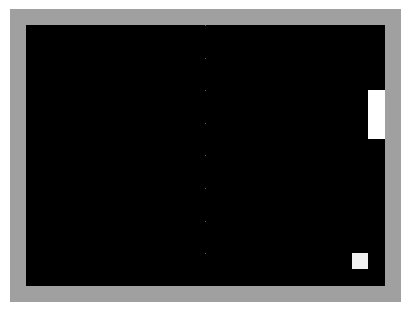

Recompensa total: -9.0 Partidas jugadas: 10
Recompensa media en 10 episodios: -0.90


In [6]:
# ====== Ejemplo del código, rellena las partes que necesites. ======

# NOTA: por el TODO en la celda anterior no sabía si tenían que ser dos implementaciones diferentes, 
# al ser diferentes dejo las dos, como esta tarda más, dejo que juege solo 10 partidas. 

env = gym.make("SimplePong-v0", render_mode="rgb_array",
               width=24, height=18, paddle_size=4, rgb_scale=18, max_steps=2000)

obs, _ = env.reset(seed=7)

fig, ax = plt.subplots(figsize=(5.5, 3.8))
frame = env.render()
im = ax.imshow(frame, interpolation="nearest")
ax.axis("off")
disp = display(fig, display_id=True)

#TODO: inicializa el recuento de recompensa total
total_r = 0.0
num_episodes = 10
for ep in range(num_episodes):
    terminated, truncated = False, False
    obs, _ = env.reset()
    while not (terminated or truncated): # TODO: condición de final (p. ej., while not terminated y not truncated)
        # TODO: elegir una acción (p. ej., acción aleatoria)
        action = env.action_space.sample()
        # actualizar imagen en el mismo display_id
        frame = env.render()
        im.set_data(frame)
        fig.canvas.draw_idle()
        disp.update(fig)
        time.sleep(0.01)
        
        new_obs, reward, terminated, truncated, info = env.step(action)
        total_r += reward

print("Recompensa total:", round(total_r, 2), "Partidas jugadas:", num_episodes)
avg_reward = total_r / num_episodes
print(f"Recompensa media en {num_episodes} episodios: {avg_reward:.2f}")
env.close()
plt.close(fig)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
  <strong>Ejercicio 1.2.2 (0,25 pto):</strong> Implementar un agente reactivo para <code>SimplePong-v0</code> que siga la pelota:
  <ul>
    <li>Cargar el entorno (parámetros de la práctica) y fijar una semilla reproducible.</li>
    <li>Programar la política que siga la pala a la pelota como se muestra en el gif</li>
    <li>Ejecutar <strong>1 episodio</strong> mostrando la animación en una <em>única figura</em> que se actualice en tiempo real (mismo <code>display_id</code>) y, al finalizar, imprimir la <strong>recompensa total</strong>.</li>
  </ul>
</div>




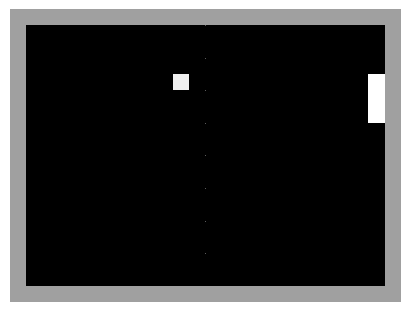

Fin de la partida, recompensa total: 0


In [7]:
# ====== DEMO EN JUPYTER (una sola figura actualizada) ======
env = gym.make("SimplePong-v0", render_mode="rgb_array",
               width=24, height=18, paddle_size=4, rgb_scale=18, max_steps=2000)

obs, _ = env.reset(seed=7)

fig, ax = plt.subplots(figsize=(5.5, 3.8))
frame = env.render()
im = ax.imshow(frame, interpolation="nearest")
ax.axis("off")
disp = display(fig, display_id=True)

# TODO: añade el código necesario para que la pala siga automáticamente a la pelota,
# reproduciendo el comportamiento mostrado en el GIF (seguir la posición vertical de la pelota).
total_r=0
terminated, truncated = False, False
obs, _ = env.reset()
while not (terminated or truncated):
    # obs -> [py, bx, by, vx, vy]
    if obs[0] > obs[2]:
        action = 0
    elif obs[0] < obs[2]:
        action = 2
    else:
        action = 1

    # actualizar imagen en el mismo display_id
    frame = env.render()
    im.set_data(frame)
    fig.canvas.draw_idle()
    disp.update(fig)
    time.sleep(0.001)  # ~50 FPS

    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    
print(f"Fin de la partida, recompensa total: {total_r}")
env.close()
plt.close(fig)

El resultado esperado es el siguiente:

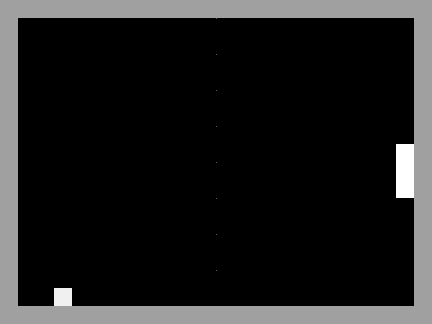

<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Fuentes Ejercicio 1:</strong>
<br><br>
PEC1 de aprendizaje automático <br>
https://gymnasium.farama.org/api/spaces/ <br>
https://gymnasium.farama.org/introduction/basic_usage/ <br>
</div>

## 2 Agente DQN jugador del Pong(2 ptos)

En este apartado implementaremos una DQN teniendo en cuenta la exploración-explotación (epsilon-*greedy*), la red objetivo, y el buffer de repetición de experiencias.

Definiremos el buffer como sigue:

In [8]:
class experienceReplayBuffer:

    def __init__(self, memory_size=50000, burn_in=10000):
        self.memory_size = memory_size
        self.burn_in = burn_in
        self.buffer = namedtuple('Buffer',
            field_names=['state', 'action', 'reward', 'done', 'next_state'])
        self.replay_memory = deque(maxlen=memory_size)

    def sample_batch(self, batch_size=32):
        samples = np.random.choice(len(self.replay_memory), batch_size,
                                   replace=False)
        # Use asterisk operator to unpack deque
        batch = zip(*[self.replay_memory[i] for i in samples])
        return batch

    def append(self, state, action, reward, done, next_state):
        self.replay_memory.append(
            self.buffer(state, action, reward, done, next_state))

    def burn_in_capacity(self):
        return len(self.replay_memory) / self.burn_in

### 2.1 Implementación de la Clase PongNeural

<br>Primeramente implementaremos la red neuronal, utilizando un modelo Secuencial con la siguiente configuración:</br>
<ul>
<li>
Tres capas completamente conectadas (representadas en pytorch por nn.Lineal) con  128 y 64 neuronas cada una, bias=True, y activación ReLU</li>
<li>Una capa de salida completamente conectada y bias=True</li>
</ul>


Usaremos el optimizador Adam para entrenar la red.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio 2.1 (0.25 ptos):</strong> Implementar la clase <code>PongNeural:()</code>. Inicializar las variables necesarias y definir el modelo Secuencial de red neuronal indicado.

-----------------------------------------------------------------------------------------------------------
<b>Nota</b>: se os proporciona el código pre-implementado. La implementación que se pide en el enunciado está indicada en los bloques <i>TODO</i> y/o con variables igualadas a <i>None</i>.
</div>

In [9]:

class PongNeural(torch.nn.Module):

    ###################################
    ###inicialización y modelo###
    def __init__(self, env, learning_rate=1e-3, optimizer = None, device=None):
        """
        Params
        ======
        n_inputs: tamaño del espacio de estados
        n_outputs: tamaño del espacio de acciones
        actions: array de acciones posibles
        """
        ######################################
        ##TODO: Inicializar parámetros
        super(PongNeural, self).__init__()
        self.n_inputs = env.observation_space.shape[0]
        self.n_outputs = env.action_space.n
        self.actions = np.arange(self.n_outputs)
        self.learning_rate = learning_rate

        # Definir el dispositivo (CPU o GPU)
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')



        #######################################
        ##Construcción de la red neuronal
        self.model = torch.nn.Sequential(
            torch.nn.Linear(self.n_inputs, 128, bias=True),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64, bias=True),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64, bias=True),
            torch.nn.ReLU(),
            torch.nn.Linear(64, self.n_outputs, bias=True)
        ) #TODO


        #######################################
        ##Inicializar el optimizador
        if optimizer is None:
            self.optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        else:
            self.optimizer = optimizer



    ### MéTODO e-greedy
    def get_action(self, state, epsilon=0.05):
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            qvals = self.get_qvals(state)  #TODO  # acción a partir del cálculo del valor de Q para esa acción
            action= torch.max(qvals, dim=-1)[1].item()
        return action


    def get_qvals(self, state):
        if type(state) is tuple:
            state = np.array([np.ravel(s) for s in state])
        state_t = torch.FloatTensor(state).to(self.device)
        return self.model(state_t)


### 2.2 Implementación del Agente DQN con Exploración/Explotación y Sincronización de Redes

A continuación implementaremos una clase que defina el comportamiento del agente DQN teniendo en cuenta:

- La **exploración/explotación** (decaimiento de epsilon)
- La **actualización y sincronización** de la red principal y la red objetivo (pérdida)
- Consideraremos que el agente ha aprendido a realizar la tarea (i.e. el "juego" termina) cuando obtiene una **media de mínimo 18.5 durante 100 episodios consecutivos**.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio 2.2  (0.75 ptos):</strong> Implementar los siguientes puntos de la clase <code>DQNAgent()</code>:

1. Declarar las variables de la clase  
2. Inicializar las variables necesarias  
3. Implementar la acción a tomar  
4. Actualizar las variables de la red principal según la frecuencia establecida en los hiperparámetros  
5. Calcular la pérdida (ecuación de Bellman, etc.)  
6. Sincronizar la red objetivo según la frecuencia establecida en los hiperparámetros  
7. Calcular la media de recompensas de los últimos 100 episodios  
8. Comprobar límite de episodios  
9. Actualizar epsilon según: $\max(\epsilon \cdot \epsilon_{\text{decay}}, 0.01)$

Además, durante el proceso se deben almacenar (*):
    <ol>
        <li>Las recompensas obtenidas en cada paso del entrenamiento</li>
        <li>Las recompensas medias cada 100 episodios</li>
        <li>La pérdida durante el entrenamiento</li>
        <li>La evolución de epsilon a lo largo del entrenamiento</li>
                 <li>Almacena la cantidad de episodios necesarios para llevar acabo el entrenamiento en la variable episodes_train_dqn </li>
    </ol>

-----------------------------------------------------------------------------------------------------------
<b>Nota</b>: se os proporciona el código pre-implementado. La implementación que se pide en el enunciado está indicada en los bloques <i>TODO</i> y/o con variables igualadas a <i>None</i>, salvo (*) donde tenéis que decidir en qué momento almacenar las variables que se indican.
</div>

In [10]:
from tqdm.auto import tqdm

class DQNAgent:
    def __init__(self, env, main_network, buffer, epsilon=0.1, eps_decay=0.99, batch_size=32, min_episodes= 300, device = None):
        ######################################
        ##TODO: Declarar variables
        self.env = env
        self.main_network = main_network
        self.target_network = PongNeural(env, learning_rate=main_network.learning_rate, device=device) # red objetivo (copia de la principal)
        self.buffer = buffer
        self.epsilon = epsilon
        self.eps_decay = eps_decay
        self.batch_size = batch_size
        self.nblock = 100 # bloque de los X últimos episodios de los que se calculará la media de recompensa
        self.initialize()
        self.min_episodes = min_episodes
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Configurar el dispositivo (CPU o GPU)

        self.main_network.to(self.device)
        self.target_network.to(self.device)
        self.target_network.load_state_dict(self.main_network.state_dict())
        self.main_network.train()
        self.target_network.eval()
        self.huber = torch.nn.SmoothL1Loss()

    def initialize(self):
        ######################################
        ##TODO: Inicializa lo necesario
        # env y estado
        self.state0 = self.env.reset()[0]
        # rewards
        self.total_reward = 0
        self.episode_rewards = []
        self.mean_rewards_100 = []
        # training history
        self.episodes_train_dqn = 0
        self.step_count = 0
        self.epsilon_history = [self.epsilon]
        self.update_loss = []

    ## Tomar nueva acción
    def take_step(self, eps, mode='train'):
        if mode == 'explore':
            # acción aleatoria en el burn-in y en la fase de exploración (epsilon)>
            action = self.env.action_space.sample()
        else:
            # acción a partir del valor de Q (elección de la acción con mejor Q)
            action = self.main_network.get_action(self.state0, self.epsilon)
            self.step_count += 1
        #TODO: tomar 'step' i obtener nuevo estado y recompensa. Guardar la experiencia en el buffer
        new_state, reward, terminated, truncated, _ = self.env.step(action)
        self.buffer.append(self.state0, action, reward, (terminated or truncated), new_state)  #(st, at, rt+1, dt, st+1)
        self.state0 = new_state
        self.total_reward += reward

        #TODO: resetear entorno 'if done'
        if (terminated or truncated):
            self.state0 = self.env.reset()[0]
            return True
        else:
            return False


    ## Entrenamiento
    def train(self, gamma=0.99, max_episodes=3000,
              batch_size=32,
              dnn_update_frequency=4,
              dnn_sync_frequency=2000, REWARD_THRESHOLD = 25):

        self.gamma = gamma

        # Rellenamos el buffer con N experiencias aleatorias ()
        print("Filling replay buffer (external burn-in)...")
        target = buffer.burn_in
        get_size = lambda: len(buffer.replay_memory)

        pbar = tqdm(total=target, desc="Replay burn-in", unit="exp")
        pbar.update(min(get_size(), target))

        while get_size() < target:
            before = get_size()
            self.take_step(self.epsilon, mode='explore') #saltaba error
            pbar.update(get_size() - before)

        pbar.close()
        print("Replay buffer lleno")



        episode = 0
        training = True
        print("Training...")
        while training:
            self.state0 = self.env.reset()[0]
            self.total_reward = 0
            gamedone = False
            while gamedone == False:
                # El agente toma una acción
                gamedone = self.take_step(self.epsilon, mode='train')
                ##################################################################################
                #####TODO:  Actualizar la red principal según la frecuencia establecida #######
                if (self.step_count % dnn_update_frequency) == 0:
                    self.update() if len(self.buffer.replay_memory) >= self.batch_size else print('incomplete buffer, skiping') #debug


                ########################################################################################
                ###TODO: Sincronizar red principal y red objetivo según la frecuencia establecida#####
                if (self.step_count % dnn_sync_frequency) == 0:
                    self.target_network.load_state_dict(self.main_network.state_dict())

                if gamedone:
                    episode += 1
                    #######################################################################################
                    ###TODO: calcular la media de recompensa de los últimos X episodios, y almacenar#####
                    self.episode_rewards.append(self.total_reward)
                    self.epsilon_history.append(self.epsilon)
                    self.episodes_train_dqn = episode
                    mean_rewards = np.mean(self.episode_rewards[-min(self.nblock, len(self.episode_rewards)):])
                    self.mean_rewards_100.append(mean_rewards)
                    batch = self.buffer.sample_batch(batch_size=self.batch_size)
                    self.update_loss.append(self.calculate_loss(batch).item())

                    #######################################################################################
                    ### TODO: Comprobar que todavía quedan episodios. Parar el aprendizaje si se llega al límite
                    # no entiendo si este TODO se refiere a lo que ya está implementado después o a algo diferente

                    print("\rEpisode {:d} Mean Rewards {:.2f} Epsilon {}\t\t".format(
                        episode, mean_rewards, self.epsilon), end="")

                    # Comprobamos que todavía quedan episodios
                    if episode >= max_episodes:
                        training = False
                        print('\nEpisode limit reached.')
                        print('\nEnvironment solved in {} episodes!'.format(
                            episode))
                        break

                    #######################################################################################
                    ### TODO: Añadir min episodes
                    if mean_rewards >= REWARD_THRESHOLD and self.min_episodes < episode :
                        training = False
                        print('\nEpisode limit reached.')
                        print('\nEnvironment solved in {} episodes!'.format(
                            episode))
                        break


                    #################################################################################
                    ######TODO: Actualizar epsilon según la velocidad de decaimiento fijada#######
                    self.epsilon = max(self.epsilon * self.eps_decay, 0.01)

        return [self.episode_rewards, self.mean_rewards_100, self.episodes_train_dqn, self.epsilon_history, self.update_loss]

    ## Cálculo de la pérdida
    def calculate_loss(self, batch):
        # Separamos las variables de la experiencia y las convertimos a tensores
        states, actions, rewards, dones, next_states = [i for i in batch]
        rewards_vals = torch.FloatTensor(rewards).to(self.device)
        actions_vals = torch.LongTensor(np.array(actions)).reshape(-1,1).to(self.device)
        dones_t = torch.tensor(dones, dtype=torch.bool).to(self.device)

        # Obtenemos los valores de Q de la red principal
        qvals = torch.gather(self.main_network.get_qvals(states), 1, actions_vals).to(self.device)
        # Obtenemos los valores de Q objetivo. El parámetro detach() evita que estos valores actualicen la red objetivo
        qvals_next = torch.max(self.target_network.get_qvals(next_states),
                               dim=-1)[0].detach().to(self.device)
        qvals_next[dones_t.bool()] = 0

        #################################################################################
        ### TODO: Calcular ecuación de Bellman
        expected_qvals = rewards_vals + self.gamma * qvals_next

        #################################################################################
        ### TODO: Calcular la pérdida (MSE) o SmoothL1Loss (recomendad)
        loss = self.huber(qvals, expected_qvals.unsqueeze(1))
        return loss



    def soft_update(self, tau=0.005):
        """Actualiza suavemente la red objetivo con Polyak averaging."""
        with torch.no_grad():
            for param_t, param in zip(self.target_network.parameters(), self.main_network.parameters()):
                param_t.data.mul_(1.0 - tau).add_(param.data, alpha=tau)


    def update(self):
        self.main_network.optimizer.zero_grad()# eliminamos cualquier gradiente pasado
        batch = self.buffer.sample_batch(batch_size=self.batch_size)# seleccionamos un conjunto del buffer
        loss = self.calculate_loss(batch)# calculamos la pérdida
        loss.backward()# hacemos la diferencia para obtener los gradientes
        torch.nn.utils.clip_grad_norm_(self.main_network.parameters(), 10.0)
        self.main_network.optimizer.step()#aplicamos los gradientes a la red neuronal

        self.soft_update()
        self.update_loss.append(loss.item())






### 2.3 Entrenamiento del Modelo

A continuación entrenaremos el modelo con los siguientes hiperparámetros:
  <ul>
  <li>Velocidad de aprendizaje: 1e-4</li>
  <li>Tamaño del batch: 64</li>
  <li>Número de episodios: 4000</li>
  <li>Número de episodios para rellenar el buffer (burn-in): 5000</li>
  <li>Frecuencia de actualización de la red neuronal: cada 3 pasos</li>
  <li>Frecuencia de sincronización con la red objetivo: cada 1000 pasos</li>
  <li>Capacidad máxima del buffer: 100000</li>
  <li>Factor de descuento (gamma): 0.99</li>
  <li>Epsilon: 1, con decaimiento de 0.997</li>
  <li>Umbral de recompensa objetivo: 18.5</li>
</ul>


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio 2.3 (Sin puntuación):</strong> Cargar el modelo de red neuronal y entrenar el agente con los hiperparámetros que see acaban de definir. Comentar los resultados del entrenamiento.
</div>

In [11]:
#definición de las variables
lr = 1e-4
batch_size = 64
num_episodes = 4000
burn_in = 5000
update_freq = 3
sync_freq = 1000
max_buffer = 100000
gamma = 0.99
epsilon = 1
epsilon_decay = 0.997
reward_goal = 18.5

#red 
buffer = experienceReplayBuffer(memory_size=max_buffer, burn_in=burn_in)
dqn = PongNeural(env=env, learning_rate=lr)
agent = DQNAgent(env=env, main_network=dqn, buffer=buffer, epsilon=epsilon, eps_decay=epsilon_decay, batch_size=batch_size)

In [12]:
# TODO: Entrenamiento
# Tiempo estimado de entrenamiento en Google Colab: ~30 minutos.
# Si al finalizar todos los episodios el agente aún no logra superar el entorno,
# vuelve a ejecutar el entrenamiento.
# Habitualmente, alrededor de los 2000-3000 episodios el agente consigue vencer el entorno
# con un tiempo de ejecución inferior a 30 minutos en Google Colab.
time_dqn_0 = time.time()
results_dqn = agent.train(
    gamma=gamma,
    max_episodes=num_episodes,
    batch_size=batch_size,
    dnn_update_frequency=update_freq,
    dnn_sync_frequency=sync_freq,
    REWARD_THRESHOLD=reward_goal
)
time_dqn_1 = time.time()
time_dqn = time_dqn_1 - time_dqn_0

Filling replay buffer (external burn-in)...


Replay burn-in: 100%|██████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 72879.52exp/s]

Replay buffer lleno
Training...
Episode 5 Mean Rewards -1.00 Epsilon 0.988053892081		

Episode 1070 Mean Rewards 18.66 Epsilon 0.04028322528557859			
Episode limit reached.

Environment solved in 1070 episodes!


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
Podemos ver el flujo de entrenamiento del agente. En primer lugar se rellena el buffer con 5000 experiencias aleatorias, luego se comienza a entrenar con una alta exploración (epsilon=0.988) y a medida que avanza se llega a epsilon=0.04, donde se alcanza la media de recompensas por 100 episodios de 18.66. Se ha podido completar el entrenamiento en 1070 episodios, lo que es bastante razonable comparado al tiempo de ejecución en google colab.
</div>

### 2.4 Análisis del entrenamiento


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio 2.4 (0.25 ptos):</strong> Representar:
    <ol>
        <li>Gráfico con las recompensas obtenidas a lo largo del entrenamieno, la evolución de las recompensas medias cada 100 episodios, y el umbral de recompensa establecido por el entorno.</li>
        <li>Gráfico con la evolución de la perdida a lo largo del entrenamiento</li>
        <li>Gráfico con la evolución de epsilon a lo largo del entrenamiento</li>
    </ol>

Comentar los resultados obtenidos.
</div>

In [13]:
def plot_rewards(tr_rewards, mean_tr_rewards, th):
  #TODO
    plt.figure(figsize=(10,6))
    plt.plot(tr_rewards, label="Recompensa por episodio", alpha=0.6)
    plt.plot(mean_tr_rewards, label="Media móvil (100 episodios)", linewidth=2, color="orange")
    plt.axhline(y=th, color="red", linestyle="--", label="Umbral de recompensa")
    plt.xlabel("Episodios")
    plt.ylabel("Recompensa")
    plt.title("Evolución de recompensas durante el entrenamiento")
    plt.legend()
    plt.grid(True)
    plt.show()


In [14]:
def plot_loss(loss_values):
  #TODO
    plt.figure(figsize=(10,6))
    plt.plot(loss_values, label="Loss")
    plt.xlabel("Actualizaciones de red")
    plt.ylabel("Pérdida")
    plt.title("Evolución de la pérdida (loss)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [15]:
def plot_epsilon(epsilon_values):
  #TODO
    plt.figure(figsize=(10,6))
    plt.plot(epsilon_values, label="Epsilon")
    plt.xlabel("Episodios")
    plt.ylabel("Epsilon")
    plt.title("Evolución de epsilon (exploración vs explotación)")
    plt.legend()
    plt.grid(True)
    plt.show()

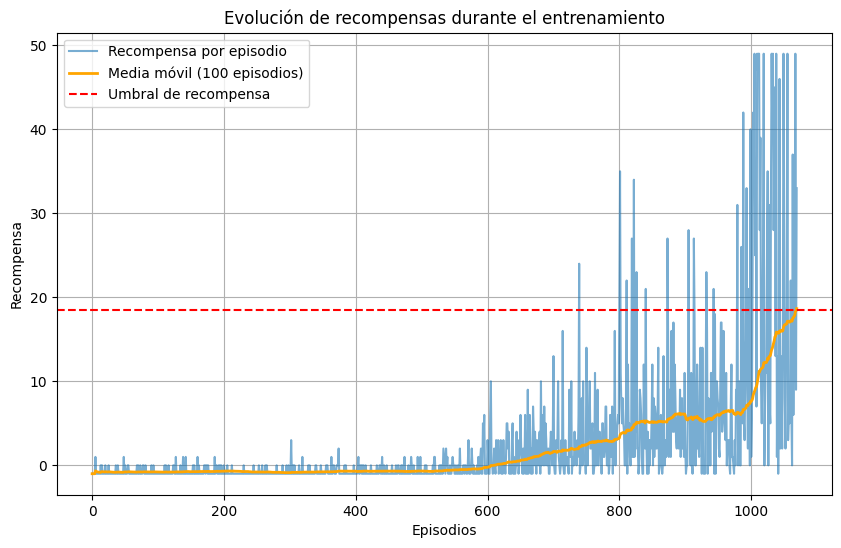

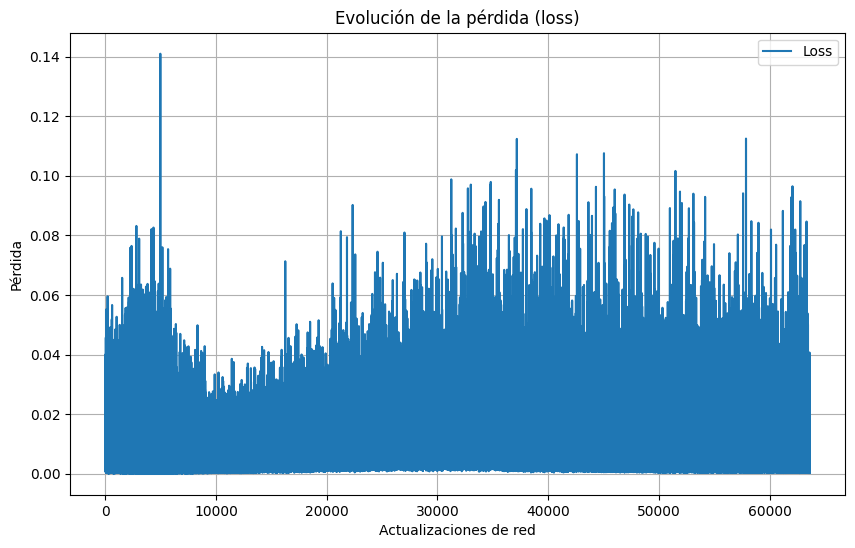

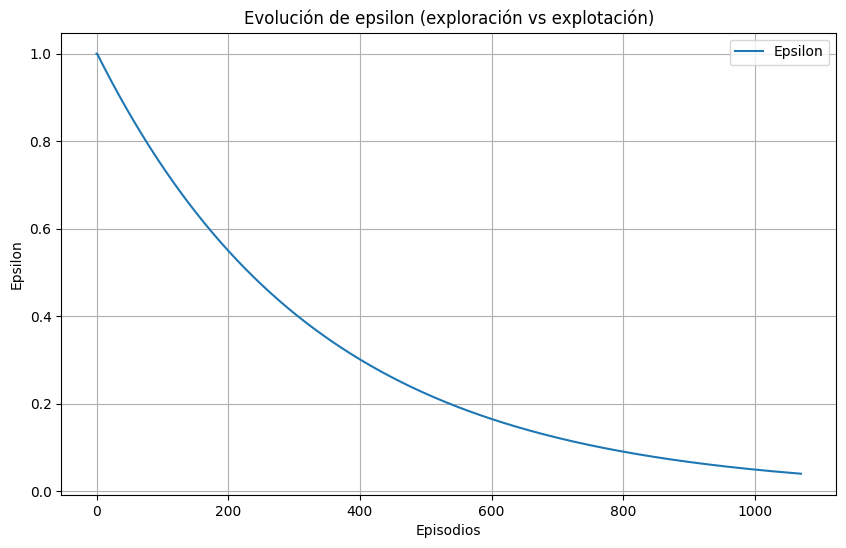

In [16]:
#TODO mostrar gráficas
plot_rewards(agent.episode_rewards, agent.mean_rewards_100, reward_goal)
plot_loss(agent.update_loss)
plot_epsilon(agent.epsilon_history)

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
Podemos ver que el agente DQN ha aprendido una política eficaz, ya que las recompensas por episodio son altas y estables, superando el umbral. La pérdida se mantiene baja, y el decaimiento de epsilon refleja una transición normal de exploración a explotación. Podemos decir entonces que el entrenamiento se completa con éxito. 
</div>

Una vez entrenado el agente, nos interesa comprobar cómo de bien ha aprendido y si es capaz de conseguir resolver el entorno. Para ello, recuperamos el modelo entrenado y dejamos que el agente tome acciones aleatorias según ese modelo y observamos su comportamiento.


### 2.5 Test del agente en Pong

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio 2.5 (0.75 ptos):</strong> Cargar el modelo entrenado y evaluar su comportamiento en el entorno <code>Pong-v0</code>.

Para ello, realiza las siguientes tareas en este orden:

<ol>
  <li><strong>Visualización de una partida:</strong> Ejecuta una partida completa del agente entrenado en el entorno Pong y muestra por pantalla el resultado final (por ejemplo, puntuación total o número de puntos ganados).<br></li>

  <li><strong>Evaluación cuantitativa:</strong> Ejecuta el agente durante <strong>20 partidas consecutivas</strong> sin renderizar y calcula las métricas de rendimiento:</li>
  <ul>
    <li>Recompensa media obtenida en las 20 partidas &rarr; almacénala en la variable <code>mean_reward_dqn_test</code>.</li>
  </ul>

  <li><strong>Gráfico de resultados:</strong> Representa un gráfico con la suma de recompensas obtenidas en las 20 partidas de test, incluyendo una línea horizontal que indique el umbral de recompensa objetivo (por ejemplo, <code>REWARD_THRESHOLD = 18</code>).</li>

  <li><strong>Análisis final:</strong> Comenta los resultados obtenidos:
    <ul>
      <li>¿Ha alcanzado el agente un rendimiento estable y superior al umbral de recompensa?</li>
      <li>¿Muestra el comportamiento esperado en Pong?</li>
      <li>¿Qué cambios podrías aplicar al entrenamiento (por ejemplo, tasa de aprendizaje, frecuencia de sincronización o epsilon decay) para mejorar su desempeño?</li>
    </ul>
  </li>
</ol>
</div>




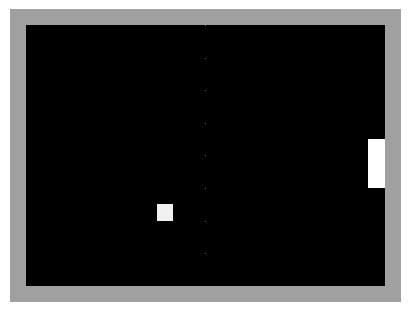

Recompensa total: 49.0


In [17]:
#TODO: Visualización de una partida
env = gym.make("SimplePong-v0", render_mode="rgb_array",
               width=24, height=18, paddle_size=4, rgb_scale=18, max_steps=2000)

obs, _ = env.reset()

fig, ax = plt.subplots(figsize=(5.5, 3.8))
frame = env.render()
im = ax.imshow(frame, interpolation="nearest")
ax.axis("off")
disp = display(fig, display_id=True)

total_r = 0.0

terminated = False
truncated = False

while not terminated and not truncated:
    
    action = agent.main_network.get_action(obs, epsilon=0.0)

    obs, reward, terminated, truncated, _ = env.step(action)
    total_r += reward

    frame = env.render()
    im.set_data(frame)
    fig.canvas.draw_idle()
    disp.update(fig)
    time.sleep(0.001)

print("Recompensa total:", round(total_r, 2))
env.close()
plt.close(fig)

Recompensa media en test: 49.00


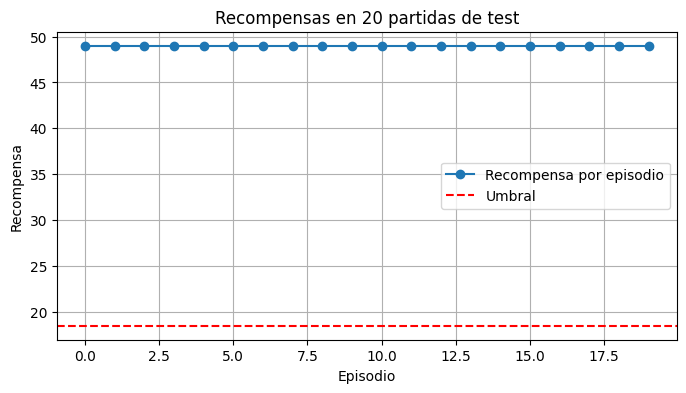

In [18]:
#TODO: Evaluación y gráfico de los resultados
env = gym.make("SimplePong-v0")
num_test_episodes = 20
episode_rewards = []

for ep in range(num_test_episodes):
    obs, _ = env.reset()
    terminated, truncated = False, False
    total_reward = 0.0

    while not (terminated or truncated):
        # Acción greedy (epsilon=0)
        action = agent.main_network.get_action(obs, epsilon=0.0)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

    episode_rewards.append(total_reward)

# Recompensa media
mean_reward_dqn_test = np.mean(episode_rewards)
print(f"Recompensa media en test: {mean_reward_dqn_test:.2f}")

# Gráfico
plt.figure(figsize=(8, 4))
plt.plot(episode_rewards, marker='o', label="Recompensa por episodio")
plt.axhline(reward_goal, color='r', linestyle='--', label='Umbral')
plt.title(f"Recompensas en {num_test_episodes} partidas de test")
plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
Es interesante ver que en algunas ejecuciones el agente obtiene una recompensa de 49.0 en todas las partidas, lo que significaría que siempre está tomando la acción óptima resultado del aprendizaje. Aunque la falta de variabilidad en las partidas podría deberse a algún error propio, también es posible que el agente haya llegado a una política óptima en la semilla utilizada.
</div>

<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Fuentes Ejercicio 2:</strong>
<br><br>
https://www.geeksforgeeks.org/deep-learning/deep-q-learning/ <br>
https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html <br>
https://www.codegenes.net/blog/get-layers-sequential-model-pytorch/ <br>
https://docs.pytorch.org/docs/main/generated/torch.nn.Sequential.html#torch.nn.Sequential <br>
https://deeplizard.com/learn/video/Bcuj2fTH4_4 <br>
</div>

## 3 Agente Dueling DQN (2 ptos)

En este apartado resolveremos el mismo entorno con las mismas características para el agente, pero usando una dueling DQN. Como en el caso anterior, primero definiremos el modelo de red neuronal, luego describiremos el comportamiento del agente, lo entrenaremos y, finalmente, testearemos el funcionamiento del agente entrenado.



### 3.1 Definición de la arquitectura  de la red neuronal


El objetivo principal de las dueling DQN es "ahorrarse" el cálculo del valor de Q en aquéllos estados en los que es irrelevante la acción que se tome. Para ello se descompone la función Q en dos componentes:


$$Q(s, a) = A(s, a) + V (s)$$


Esta descomposición se realiza a nivel de la arquitectura de la red neuronal. Las primeras capas que teníamos en la DQN serán comunes, y luego la red se dividirá en dos partes separadas definidas por el resto de capas.


La descomposición en sub-redes del modelo de la DQN implementada en el apartado anterior, será entonces:

<ol> <li> Bloque común: </li> <ul> <li>Una primera capa completamente conectada de 128 neuronas y <code>bias = True</code>, con activación ReLU </li> </ul> <li>Para cada una de las subredes de ventaja A(s,a) y valor V(s):</li> <ul> <li>Una capa completamente conectada de 64 neuronas y <code>bias = True</code>, con activación ReLU </li> <li>Una última capa completamente conectada y <code>bias = True</code>. Esta será nuestra capa de salida y por tanto el número de neuronas de salida dependerá de si se trata de la red A(s,a), que tendrá tantas neuronas como dimensiones tenga el espacio de acciones, o si se trata de la red V(s), con un valor por estado.</li> </ul> </ol>

     




<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio 3.1 (0.25 ptos):</strong> Implementar la clase <code>duelingDQN()</code>. Inicializar las variables necesarias y definir el modelo de red neuronal indicado.

-----------------------------------------------------------------------------------------------------------
<b>Nota</b>: se os proporciona el código pre-implementado. La implementación que se pide en el enunciado está indicada en los bloques <i>TODO</i> y/o con variables igualadas a <i>None</i>.
</div>


In [19]:
import torch.autograd as autograd

class duelingDQN(torch.nn.Module):

    def __init__(self, env, device=None, learning_rate=1e-3):

        """
        Parámetros
        ==========
        n_inputs: tamaño del espacio de estados
        n_outputs: tamaño del espacio de acciones
        actions: array de acciones posibles
        """

        ###################################
        ####TODO: Inicializar variables####
        super(duelingDQN, self).__init__()
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        self.n_inputs = env.observation_space.shape[0]
        self.n_outputs = env.action_space.n
        self.actions = list(range(self.n_outputs))

        ######


        #######################################
        ##TODO: Construcción de la red neuronal
        # Red común
        ##Construcción de la red neuronal
        #capa de entrada
        self.model_common = torch.nn.Sequential(
            torch.nn.Linear(self.n_inputs, 128, bias=True),
            torch.nn.ReLU()
        ).to(self.device)

        # Subred de la función de Valor
        self.fc_layer_inputs = self.feature_size()
        
        self.value = torch.nn.Sequential(
            torch.nn.Linear(self.fc_layer_inputs , 64, bias=True),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1, bias=True)
        ).to(self.device)

        # Recordad adaptarlas a cpu o gpu

        # Subred de la Ventaja A(s,a)
        self.advantage  = torch.nn.Sequential(
            torch.nn.Linear(self.fc_layer_inputs , 64, bias=True),
            torch.nn.ReLU(),
            torch.nn.Linear(64, self.n_outputs, bias=True)
        ).to(self.device)

        #######
        #######################################
        ##TODO: Inicializar el optimizador
        self.optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)





    #######################################
    #####TODO: función forward#############
    def forward(self, state):


        # Conexión entre capas de la red común
        common_out = self.model_common(state)

        # Conexión entre capas de la Subred de Valor
        advantage = self.advantage(common_out)

        # Conexión entre capas de la Subred de Ventaja
        value = self.value(common_out)


        ## Agregar las dos subredes:
        # Q(s,a) = V(s) + (A(s,a) - 1/|A| * sum A(s,a'))
        action = value + advantage - advantage.mean(dim=1, keepdim=True) # valores de q
        return action





        #return action


    #######



    ### Método e-greedy
    def get_action(self, state, epsilon=0.05):
        if np.random.random() < epsilon:
            action = np.random.choice(self.actions)
        else:
            qvals = self.get_qvals(state)
            action = torch.max(qvals, dim=-1)[1].item()
        return action



    def get_qvals(self, state):
        # state: np.array o list/tuple
        state = np.array(state, dtype=np.float32)
        if state.ndim == 1:
            state = state[None, :]
        state_t = torch.from_numpy(state).to(self.device)
        return self.forward(state_t)



    def feature_size(self):
        dummy_input = torch.zeros(1, self.n_inputs).to(self.device)
        return self.model_common(dummy_input).view(1, -1).size(1)


Para el buffer de repetición de experiencias podemos usar exactamente la misma clase experienceReplayBuffer descrita en el apartado anterior de la DQN.


### 3.2 Definición del agente

La diferencia entre la DQN y la dueling DQN se centra, como hemos visto, en la definición de la arquitectura de la red. Pero el proceso de aprendizaje y actualización es exactamente el mismo. Así, podemos recuperar la clase implementada en el apartado anterior, DQNAgent() y reutilizarla aquí bajo el nombre de duelingDQNAgent(). Lo único que deberemos hacer es añadir el optimizador entre las variables a declarar y adaptar la función de pérdida al formato Functional de pytorch.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio 3.2 (0.75 pto):</strong> Implementar la clase <code>duelingDQNAgent()</code> como la <code>DQNAgent()</code>
<p>
</p>
De nuevo, durante el proceso se deben almacenar (*):
    <ul>
        <li>Las recompensas obtenidas en cada paso del entrenamiento</li>
        <li>Las recompensas medias de los 100 episodios anteriores</li>
        <li>La pérdida durante el entrenamiento</li>
        <li>La evolución de epsilon a lo largo del entrenamiento</li>
    </ul>

-----------------------------------------------------------------------------------------------------------
<b>Nota</b>: se os proporciona el código pre-implementado. La implementación que se pide en el enunciado está indicada en los bloques <i>TODO</i> y/o con variables igualadas a <i>None</i>, salvo (*) en qué momento almacenar las variables que se indican.

In [20]:
class duelingDQNAgent:

    def __init__(self, env, main_network, buffer, reward_threshold, epsilon=0.1, eps_decay=0.99, batch_size=32, device= None):
        """"
        Params
        ======
        env: entorno
        target_network: clase con la red neuronal diseñada
        target_network: red objetivo
        buffer: clase con el buffer de repetición de experiencias
        epsilon: epsilon
        eps_decay: epsilon decay
        batch_size: batch size
        nblock: bloque de los X últimos episodios de los que se calculará la media de recompensa
        reward_threshold: umbral de recompensa definido en el entorno
        """
        self.device = torch.device(device if device else ('cuda' if torch.cuda.is_available() else 'cpu'))



        ###############################################################
        #####TODO 1: inicialitzar variables######

        self.env = env #TODO
        self.main_network = main_network #TODO
        self.target_network = type(main_network)(env).to(self.device)  #TODO  # red objetivo (copia de la principal)
        self.buffer = buffer #TODO
        self.epsilon = epsilon #TODO
        self.eps_decay = eps_decay #TODO
        self.batch_size = batch_size #TODO
        self.nblock = 100 #TODO # bloque de los X últimos episodios de los que se calculará la media de recompensa
        self.reward_threshold = reward_threshold #umbral de recompensa definido en el entorno

        self.initialize()


    ###############################################################
    #####TODO 2: inicialitzar variables extra que se necessiten######
    def initialize(self):
        # env y estado
        self.state0 = self.env.reset()[0]
        # rewards
        self.total_reward = 0
        self.episode_rewards = []
        self.mean_rewards_100 = []
        # training history
        self.episodes_train_dqn = 0
        self.step_count = 0
        self.epsilon_history = [self.epsilon]
        self.update_loss = []
        
        #TODO




    #################################################################################
    ######TODO 3:  Tomar nueva acción ###############################################
    def take_step(self, eps, mode='train'):
        if mode == 'explore':
            action = self.env.action_space.sample()  # TODO acción aleatoria en el burn-in
        else:
           action = self.main_network.get_action(self.state0, self.epsilon) # TODO  acción a partir del valor de Q (elección de la acción con mejor Q)
           self.step_count += 1

        #TODO: Realización de la acción y obtención del nuevo estado y la recompensa
        new_state, reward, terminated, truncated, _ = self.env.step(action)
        self.buffer.append(self.state0, action, reward, (terminated or truncated), new_state)  #(st, at, rt+1, dt, st+1)
        self.state0 = new_state
        self.total_reward += reward

        #TODO: resetear entorno 'if done'
        if (terminated or truncated):
            self.state0 = self.env.reset()[0]
            return True
        else:
            return False



    ## Entrenamiento
    def train(self, gamma=0.99, max_episodes=50000,
              batch_size=32,
              dnn_update_frequency=4,
              dnn_sync_frequency=2000, min_episodios=250):
        self.gamma = gamma
        # Rellenamos el buffer con N experiencias aleatorias ()
        print("Filling replay buffer (external burn-in)...")
        target = self.buffer.burn_in

        get_size = lambda: len(self.buffer.replay_memory)

        pbar = tqdm(total=target, desc="Replay burn-in", unit="exp")
        pbar.update(min(get_size(), target))

        while get_size() < target:
            before = get_size()
            self.take_step(self.epsilon, mode='explore')
            pbar.update(get_size() - before)

        pbar.close()
        print("Replay buffer lleno")





        episode = 0
        training = True
        print("Training...")
        while training:
            self.state0 = self.env.reset()[0]
            self.total_reward = 0
            gamedone = False
            while gamedone == False:
                # El agente toma una acción
                gamedone = self.take_step(self.epsilon, mode='train')

                #################################################################################
                #####TODO : Actualizar la red principal según la frecuencia establecida  #######
                if self.step_count % dnn_update_frequency == 0:
                    self.update()

                ########################################################################################
                ###TODO: Sincronizar red principal y red objetivo según la frecuencia establecida#####
                if self.step_count % dnn_sync_frequency == 0:
                    self.target_network.load_state_dict(
                        self.main_network.state_dict())
                    #self.sync_eps.append(episode)

                if gamedone:
                    episode += 1
                    ##################################################################
                    ########TODO: Almacenar epsilon, training rewards i loss#######
                    self.epsilon_history.append(self.epsilon)
                    self.episode_rewards.append(self.total_reward)
                    self.episodes_train_dqn = episode
                    ####
                    batch = self.buffer.sample_batch(batch_size=self.batch_size)
                    self.update_loss.append(self.calculate_loss(batch).item())


                    #######################################################################################
                    ###TODO : calcular la media de recompensa de los últimos X episodios, y almacenar#####
                    mean_rewards = np.mean(self.episode_rewards[-self.nblock:])
                    self.mean_rewards_100.append(mean_rewards)
                    ###

                    print("\rEpisode {:d} Mean Rewards {:.2f} Epsilon {}\t\t".format(
                        episode, mean_rewards, self.epsilon), end="")

                    # Comprobar si se ha llegado al máximo de episodios
                    if episode >= max_episodes:
                        training = False
                        print('\nEpisode limit reached.')
                        break

                    # Termina el juego si la media de recompensas ha llegado al umbral fijado para este juego
                    # y se ha entrenado un mínimo de episodios
                    if mean_rewards >= self.reward_threshold and min_episodios <  episode:
                        training = False
                        print('\nEnvironment solved in {} episodes!'.format(
                            episode))
                        break

                    #################################################################################
                    ######TODO : Actualizar epsilon ########
                    self.epsilon = max(self.epsilon * self.eps_decay, 0.01)

        return [self.episode_rewards, self.mean_rewards_100, self.episodes_train_dqn, self.epsilon_history, self.update_loss]





     ## Cálculo de la pérdida
    def calculate_loss(self, batch):
        states, actions, rewards, dones, next_states = [i for i in batch]
        rewards_vals = torch.FloatTensor(rewards).to(self.device).reshape(-1,1)
        actions_vals = torch.LongTensor(np.array(actions)).reshape(-1,1).to(self.device)
        dones_t = torch.tensor(dones, dtype=torch.bool, device=self.device)


        # Obtenemos los valores de Q de la red principal
        qvals = torch.gather(self.main_network.get_qvals(states).to(self.device), 1, actions_vals)
        next_actions = torch.max(self.main_network.get_qvals(next_states).to(self.device), dim=-1)[1]
        next_actions_vals = next_actions.reshape(-1, 1).to(self.device)


        # Obtenemos los valores de Q de la red objetivo
        target_qvals = self.target_network.get_qvals(next_states).to(self.device)
        qvals_next = torch.gather(target_qvals, 1, next_actions_vals).detach()
        #####
        qvals_next[dones_t.squeeze()] = 0


        # Calculamos ecuación de Bellman
        expected_qvals = rewards_vals + self.gamma * qvals_next
        #Función Loss #####
        loss = F.mse_loss(qvals, expected_qvals)
        #######
        return loss


    def update(self):
        self.main_network.optimizer.zero_grad()  # eliminamos cualquier gradiente pasado
        batch = self.buffer.sample_batch(batch_size=self.batch_size) # seleccionamos un conjunto del buffer
        loss = self.calculate_loss(batch) # calculamos la pérdida
        loss.backward() # hacemos la diferencia para obtener los gradientes


        torch.nn.utils.clip_grad_norm_(self.main_network.parameters(), 10.0)


        self.main_network.optimizer.step() # aplicamos los gradientes a la red neuronal
        # Guardamos los valores de pérdida
        if self.device.type == 'cuda':
            self.update_loss.append(loss.detach().cpu().numpy())
        else:
            self.update_loss.append(loss.detach().numpy())


### 3.3 Entrenamiento del Modelo

A continuación entrenaremos el modelo dueling DQN con los mismos hiperparámetros con los que entrenamos la DQN.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio 3.3 (Sin puntuación):</strong> Cargar el modelo de red neuronal y entrenar el agente con los mismos hiperparámetros usados para la DQN
</div>


In [21]:
#lo esperado es  que el modelo no consiga vencer el entorno.
#definición de las variables
lr = 1e-4
batch_size = 64
num_episodes = 4000
burn_in = 5000
update_freq = 3
sync_freq = 1000
max_buffer = 100000
gamma = 0.99
epsilon = 1
epsilon_decay = 0.997
reward_goal = 18.5

#red 
buffer = experienceReplayBuffer(memory_size=max_buffer, burn_in=burn_in)
dqn = duelingDQN(env=env, learning_rate=lr)
agent = duelingDQNAgent(env=env, main_network=dqn, buffer=buffer, reward_threshold=reward_goal, epsilon=epsilon, eps_decay=epsilon_decay, batch_size=batch_size)

time_dueling_0 = time.time()
results_dueling = agent.train(
    gamma=gamma,
    max_episodes=num_episodes,
    batch_size=batch_size,
    dnn_update_frequency=update_freq,
    dnn_sync_frequency=sync_freq
)
time_dueling_1 = time.time()
time_dueling = time_dueling_1 - time_dueling_0

Filling replay buffer (external burn-in)...


Replay burn-in: 100%|█████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 101342.53exp/s]

Replay buffer lleno
Training...
Episode 4 Mean Rewards -0.75 Epsilon 0.991026973		

Episode 1105 Mean Rewards 18.73 Epsilon 0.036262252368759296		
Environment solved in 1105 episodes!


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
Vemos que en este caso ha tardado ligeramente más episodios en completar el entrenamiento comparado con el modelos anterior (1070), pero es una diferencia descartable, por lo que el entrenamiento resulta muy similar al modelo anterior.
</div>

### 3.4 Análisis del entrenamiento

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio 3.4 (0.25 ptos):</strong> Mostrar los mismos gráficos que con la DQN:
    <ol>
        <li>Recompensas obtenidas a lo largo del entrenamieno y la evolución de las recompensas medias cada 100 episodios, junto con el umbral de recompensa establecido por el entorno</li>
        <li>Pérdida durante el entrenamiento</li>
        <li>Evolución de epsilon a lo largo del entrenamiento</li>
    </ol>
</div>

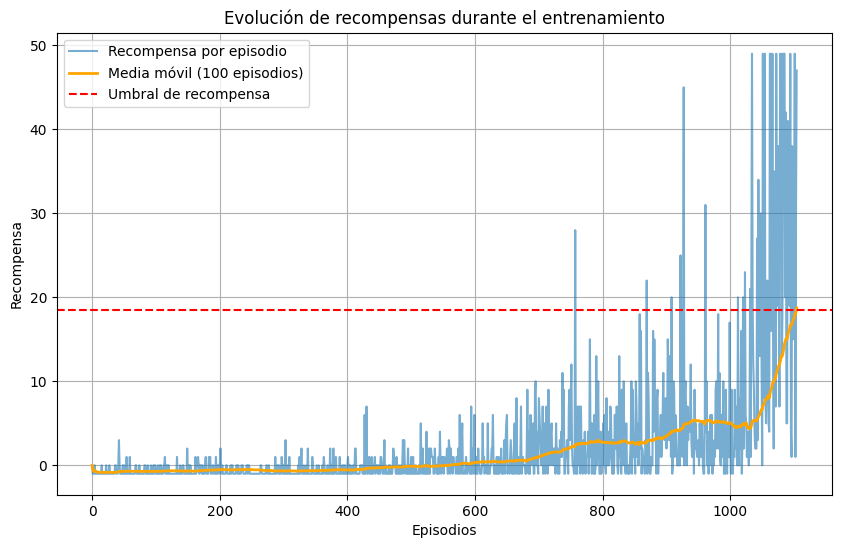

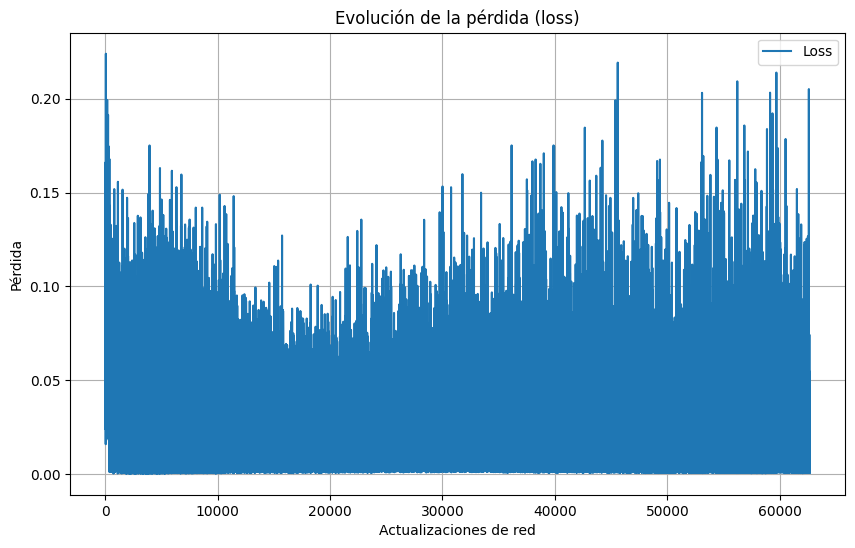

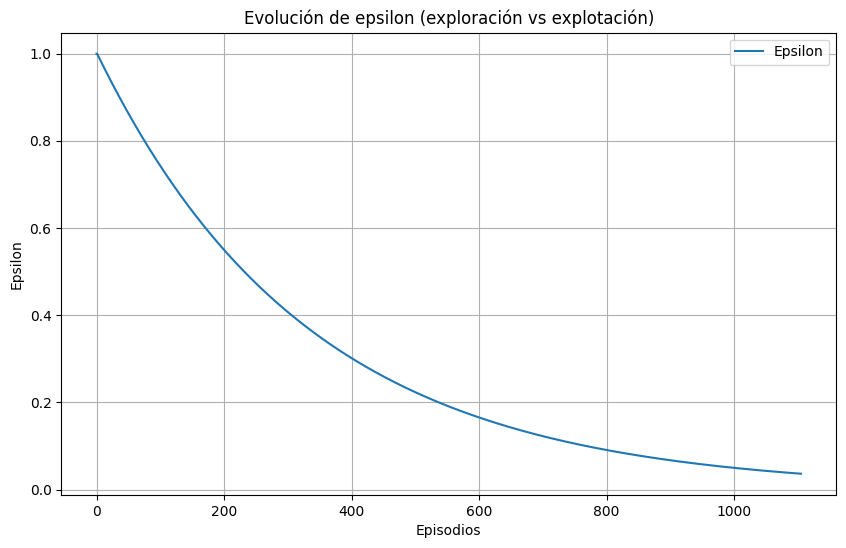

In [22]:
#TODO mostrar gráficas
plot_rewards(agent.episode_rewards, agent.mean_rewards_100, reward_goal)
plot_loss(agent.update_loss)
plot_epsilon(agent.epsilon_history)

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
Vemos una distribución bastante similar al ejercicio anterior, con una evolución de pérdida y entrenamiento parecidas. El entrenamiento se pausa cuando la media movil de los últimos 100 episodios es 18.5, lo que coincide con que se obtenga una media por episodio de 49.0. Esto indica que los modelos no resultan muy diferentes entre si en terminos de política alcanzada, ni tampoco en cuanto a tiempos de entrenamiento.
</div>


### 3.5 Test del agente en Pong

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio 3.5 (0.75 ptos):</strong> Cargar el modelo entrenado y evaluar su comportamiento en el entorno <code>Pong-v0</code>.

Para ello, realiza las siguientes tareas en este orden:

<ol>
  <li><strong>Visualización de una partida:</strong> Ejecuta una partida completa del agente entrenado en el entorno Pong y muestra por pantalla el resultado final (por ejemplo, puntuación total o número de puntos ganados).<br></li>

  <li><strong>Evaluación cuantitativa:</strong> Ejecuta el agente durante <strong>20 partidas consecutivas</strong> sin renderizar y calcula las métricas de rendimiento:</li>
  <ul>
    <li>Recompensa media obtenida en las 20 partidas &rarr; almacénala en la variable <code>mean_reward_dqn_test</code>.</li>
  </ul>

  <li><strong>Gráfico de resultados:</strong> Representa un gráfico con la suma de recompensas obtenidas en las 20 partidas de test, incluyendo una línea horizontal que indique el umbral de recompensa objetivo (por ejemplo, <code>REWARD_THRESHOLD = 18</code>).</li>

  <li><strong>Análisis final:</strong> Comenta los resultados obtenidos:
    <ul>
      <li>¿Ha alcanzado el agente un rendimiento estable y superior al umbral de recompensa?</li>
      <li>¿Muestra el comportamiento esperado en Pong?</li>
<li>¿El modelo mejora al anterior? Justifica la respuesta con base teórica.</li>
    </ul>
  </li>
</ol>
</div>




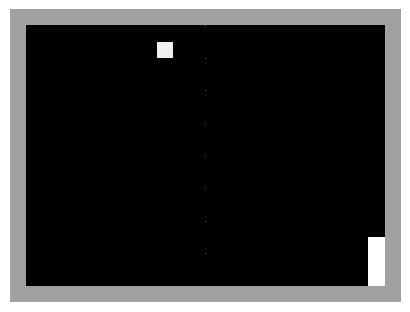

Recompensa total: 49.0


In [23]:
#TODO: Visualización de una partida
env = gym.make("SimplePong-v0", render_mode="rgb_array",
               width=24, height=18, paddle_size=4, rgb_scale=18, max_steps=2000)

obs, _ = env.reset()

fig, ax = plt.subplots(figsize=(5.5, 3.8))
frame = env.render()
im = ax.imshow(frame, interpolation="nearest")
ax.axis("off")
disp = display(fig, display_id=True)

total_r = 0.0

terminated = False
truncated = False

while not terminated and not truncated:
    
    action = agent.main_network.get_action(obs, epsilon=0.0)

    obs, reward, terminated, truncated, _ = env.step(action)
    total_r += reward

    frame = env.render()
    im.set_data(frame)
    fig.canvas.draw_idle()
    disp.update(fig)
    time.sleep(0.001)

print("Recompensa total:", round(total_r, 2))
env.close()
plt.close(fig)

Recompensa media en test: 49.00


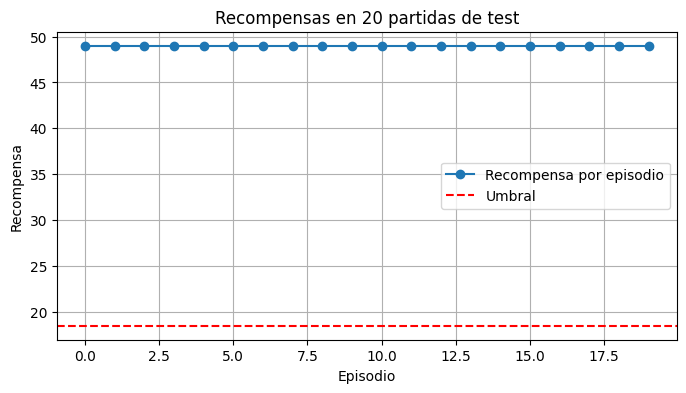

In [24]:
#TODO: Evaluación y gráfico de los resultados
env = gym.make("SimplePong-v0")
num_test_episodes = 20
episode_rewards = []

for ep in range(num_test_episodes):
    obs, _ = env.reset()
    terminated, truncated = False, False
    total_reward = 0.0

    while not (terminated or truncated):
        # Acción greedy (epsilon=0)
        action = agent.main_network.get_action(obs, epsilon=0.0)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

    episode_rewards.append(total_reward)

# Recompensa media
mean_reward_dqn_test = np.mean(episode_rewards)
print(f"Recompensa media en test: {mean_reward_dqn_test:.2f}")

# Gráfico
plt.figure(figsize=(8, 4))
plt.plot(episode_rewards, marker='o', label="Recompensa por episodio")
plt.axhline(reward_goal, color='r', linestyle='--', label='Umbral')
plt.title(f"Recompensas en {num_test_episodes} partidas de test")
plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
De la misma forma que en el ejercicio anterior, vemos que se alcanza una puntuación de 49 en todas las partidas jugadas, lo que puede ser debido a que se alcance una política similar y muy cercana a la óptima. esto es consistente con la gráfica anterior, en la que vemos que aproximadamente cuando se detiene el entrenamiento, el modelo alcanza consistentemente una recompensa por episodio de unos 49.0, lo que probablemente indica que en esta semilla se alcanza esta puntuación para todas las 20 partidas jugadas, pero no tendría por qué repetirse en cualquier otro caso.
</div>

<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Fuentes Ejercicio 3:</strong>
<br><br>
https://www.youtube.com/watch?v=XjsY8-P4WHM&t=46s <br>
https://markelsanz14.medium.com/introducci%C3%B3n-al-aprendizaje-por-refuerzo-parte-4-double-dqn-y-dueling-dqn-b24ac0a5a46c <br>
</div>

## 4 Double DQN (2 ptos)

En este apartado implementaremos una doble DQN con la misma red neuronal y características de la DQN del apartado 2.

Recordemos que con la doble DQN, es la red principal la que elije la acción con mayor valor de Q, y la red objetivo la que proporciona el valor objetivo de Q para esa
acción, es decir, la que dirá qué recompensa tiene esa acción elegida por la red principal.

Siguiendo el mismo esquema que en el ejercicio anterior, a continuación implementaremos una clase que defina el entrenamiento del agente teniendo en cuenta:
    <ul>
        <li>La exploración/explotación (decaimiento de epsilon)</li>
        <li>La actualización y sincronización de la red principal y la red objetivo (pérdida)</li>
    </ul>

 <div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio 4.1 (0.75 ptos):</strong> Implementar la clase <code>DDQNAgent()</code>siguiendo el mismo esquema de implementación realizado con el método <code>DQNAgent()</code>
</div>

    


In [25]:
from tqdm.auto import tqdm

class doubleDQNAgent:
    def __init__(self, env, main_network, buffer, epsilon=0.1, eps_decay=0.99, batch_size=32, min_episodes= 300, device = None):
        ######################################
        ##TODO: Declarar variables
        self.env = env
        self.main_network = main_network
        self.target_network = PongNeural(env, learning_rate=main_network.learning_rate, device=device) # red objetivo (copia de la principal)
        self.buffer = buffer
        self.epsilon = epsilon
        self.eps_decay = eps_decay
        self.batch_size = batch_size
        self.nblock = 100 # bloque de los X últimos episodios de los que se calculará la media de recompensa
        self.initialize()
        self.min_episodes = min_episodes
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Configurar el dispositivo (CPU o GPU)

        self.main_network.to(self.device)
        self.target_network.to(self.device)
        self.target_network.load_state_dict(self.main_network.state_dict())
        self.main_network.train()
        self.target_network.eval()
        self.huber = torch.nn.SmoothL1Loss()

    def initialize(self):
        ######################################
        ##TODO: Inicializa lo necesario
        # env y estado
        self.state0 = self.env.reset()[0]
        # rewards
        self.total_reward = 0
        self.episode_rewards = []
        self.mean_rewards_100 = []
        # training history
        self.episodes_train_dqn = 0
        self.step_count = 0
        self.epsilon_history = [self.epsilon]
        self.update_loss = []

    ## Tomar nueva acción
    def take_step(self, eps, mode='train'):
        if mode == 'explore':
            # acción aleatoria en el burn-in y en la fase de exploración (epsilon)>
            action = self.env.action_space.sample()
        else:
            # acción a partir del valor de Q (elección de la acción con mejor Q)
            action = self.main_network.get_action(self.state0, self.epsilon)
            self.step_count += 1
        #TODO: tomar 'step' i obtener nuevo estado y recompensa. Guardar la experiencia en el buffer
        new_state, reward, terminated, truncated, _ = self.env.step(action)
        self.buffer.append(self.state0, action, reward, (terminated or truncated), new_state)  #(st, at, rt+1, dt, st+1)
        self.state0 = new_state
        self.total_reward += reward

        #TODO: resetear entorno 'if done'
        if (terminated or truncated):
            self.state0 = self.env.reset()[0]
            return True
        else:
            return False


    ## Entrenamiento
    def train(self, gamma=0.99, max_episodes=3000,
              batch_size=32,
              dnn_update_frequency=4,
              dnn_sync_frequency=2000, REWARD_THRESHOLD = 25):

        self.gamma = gamma

        # Rellenamos el buffer con N experiencias aleatorias ()
        print("Filling replay buffer (external burn-in)...")
        target = buffer.burn_in
        get_size = lambda: len(buffer.replay_memory)

        pbar = tqdm(total=target, desc="Replay burn-in", unit="exp")
        pbar.update(min(get_size(), target))

        while get_size() < target:
            before = get_size()
            self.take_step(self.epsilon, mode='explore') #saltaba error
            pbar.update(get_size() - before)

        pbar.close()
        print("Replay buffer lleno")



        episode = 0
        training = True
        print("Training...")
        while training:
            self.state0 = self.env.reset()[0]
            self.total_reward = 0
            gamedone = False
            while gamedone == False:
                # El agente toma una acción
                gamedone = self.take_step(self.epsilon, mode='train')
                ##################################################################################
                #####TODO:  Actualizar la red principal según la frecuencia establecida #######
                if (self.step_count % dnn_update_frequency) == 0:
                    self.update() if len(self.buffer.replay_memory) >= self.batch_size else print('incomplete buffer, skiping') #debug


                ########################################################################################
                ###TODO: Sincronizar red principal y red objetivo según la frecuencia establecida#####
                if (self.step_count % dnn_sync_frequency) == 0:
                    self.target_network.load_state_dict(self.main_network.state_dict())

                if gamedone:
                    episode += 1
                    #######################################################################################
                    ###TODO: calcular la media de recompensa de los últimos X episodios, y almacenar#####
                    self.episode_rewards.append(self.total_reward)
                    self.epsilon_history.append(self.epsilon)
                    self.episodes_train_dqn = episode
                    mean_rewards = np.mean(self.episode_rewards[-min(self.nblock, len(self.episode_rewards)):])
                    self.mean_rewards_100.append(mean_rewards)
                    batch = self.buffer.sample_batch(batch_size=self.batch_size)
                    self.update_loss.append(self.calculate_loss(batch).item())

                    #######################################################################################
                    ### TODO: Comprobar que todavía quedan episodios. Parar el aprendizaje si se llega al límite
                    # no entiendo si este TODO se refiere a lo que ya está implementado después o a algo diferente

                    print("\rEpisode {:d} Mean Rewards {:.2f} Epsilon {}\t\t".format(
                        episode, mean_rewards, self.epsilon), end="")

                    # Comprobamos que todavía quedan episodios
                    if episode >= max_episodes:
                        training = False
                        print('\nEpisode limit reached.')
                        print('\nEnvironment solved in {} episodes!'.format(
                            episode))
                        break

                    #######################################################################################
                    ### TODO: Añadir min episodes
                    if mean_rewards >= REWARD_THRESHOLD and self.min_episodes < episode :
                        training = False
                        print('\nEpisode limit reached.')
                        print('\nEnvironment solved in {} episodes!'.format(
                            episode))
                        break


                    #################################################################################
                    ######TODO: Actualizar epsilon según la velocidad de decaimiento fijada#######
                    self.epsilon = max(self.epsilon * self.eps_decay, 0.01)

        return [self.episode_rewards, self.mean_rewards_100, self.episodes_train_dqn, self.epsilon_history, self.update_loss]

    ## Cálculo de la pérdida
    def calculate_loss(self, batch):
        # Separamos las variables de la experiencia y las convertimos a tensores
        states, actions, rewards, dones, next_states = [i for i in batch]
        rewards_vals = torch.FloatTensor(rewards).to(self.device)
        actions_vals = torch.LongTensor(np.array(actions)).reshape(-1,1).to(self.device)
        dones_t = torch.tensor(dones, dtype=torch.bool).to(self.device)

        #### Implementación doubleDQN ####
        # Obtenemos los valores de Q de la red principal
        qvals = torch.gather(self.main_network.get_qvals(states), 1, actions_vals)
        actions_vals = actions_vals.long()  # aseguramos tipo entero
        next_actions = self.main_network.get_qvals(next_states).argmax(1).unsqueeze(1)
        # Obtenemos los valores de Q objetivo. El parámetro detach() evita que estos valores actualicen la red objetivo
        qvals_next = torch.gather(self.target_network.get_qvals(next_states), 1, next_actions).detach().to(self.device)
        qvals_next[dones_t.bool()] = 0

        #################################################################################
        ### TODO: Calcular ecuación de Bellman
        expected_qvals = rewards_vals.unsqueeze(1) + self.gamma * qvals_next

        #################################################################################
        ### TODO: Calcular la pérdida (MSE) o SmoothL1Loss (recomendad)
        loss = self.huber(qvals, expected_qvals)
        return loss



    def soft_update(self, tau=0.005):
        """Actualiza suavemente la red objetivo con Polyak averaging."""
        with torch.no_grad():
            for param_t, param in zip(self.target_network.parameters(), self.main_network.parameters()):
                param_t.data.mul_(1.0 - tau).add_(param.data, alpha=tau)


    def update(self):
        self.main_network.optimizer.zero_grad()# eliminamos cualquier gradiente pasado
        batch = self.buffer.sample_batch(batch_size=self.batch_size)# seleccionamos un conjunto del buffer
        loss = self.calculate_loss(batch)# calculamos la pérdida
        loss.backward()# hacemos la diferencia para obtener los gradientes
        torch.nn.utils.clip_grad_norm_(self.main_network.parameters(), 10.0)
        self.main_network.optimizer.step()#aplicamos los gradientes a la red neuronal

        self.soft_update()
        self.update_loss.append(loss.item())






A continuación entrenaremos el modelo con los mismos hiperparámetros que con la DQN.
<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio 4.2 (0.25 ptos):</strong> Entrenar el agente.
</div>

In [26]:
#TODO: Realizar el entrenamiento
#definición de las variables
lr = 1e-4
batch_size = 64
num_episodes = 4000
burn_in = 5000
update_freq = 3
sync_freq = 1000
max_buffer = 100000
gamma = 0.99
epsilon = 1
epsilon_decay = 0.997
reward_goal = 18.5

#red 
buffer = experienceReplayBuffer(memory_size=max_buffer, burn_in=burn_in)
dqn = PongNeural(env=env, learning_rate=lr)
agent = doubleDQNAgent(env=env, main_network=dqn, buffer=buffer, epsilon=epsilon, eps_decay=epsilon_decay, batch_size=batch_size)

time_ddqn_0 = time.time()
results_ddqn = agent.train(
    gamma=gamma,
    max_episodes=num_episodes,
    batch_size=batch_size,
    dnn_update_frequency=update_freq,
    dnn_sync_frequency=sync_freq,
    REWARD_THRESHOLD=reward_goal
)
time_ddqn_1 = time.time()
time_ddqn = time_ddqn_1 - time_ddqn_0 

Filling replay buffer (external burn-in)...


Replay burn-in: 100%|██████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 43719.08exp/s]

Replay buffer lleno
Training...
Episode 2 Mean Rewards -1.00 Epsilon 0.997		

Episode 968 Mean Rewards 18.56 Epsilon 0.054729072399896876		
Episode limit reached.

Environment solved in 968 episodes!


### 4.1 Análisis del entrenamiento

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio 4.3 (0.25 ptos):</strong> Mostrar los mismos gráficos que con la Double DQN:
    <ol>
        <li>Recompensas obtenidas a lo largo del entrenamieno y la evolución de las recompensas medias cada 100 episodios, junto con el umbral de recompensa establecido por el entorno</li>
        <li>Pérdida durante el entrenamiento</li>
        <li>Evolución de epsilon a lo largo del entrenamiento</li>
    </ol>
</div>

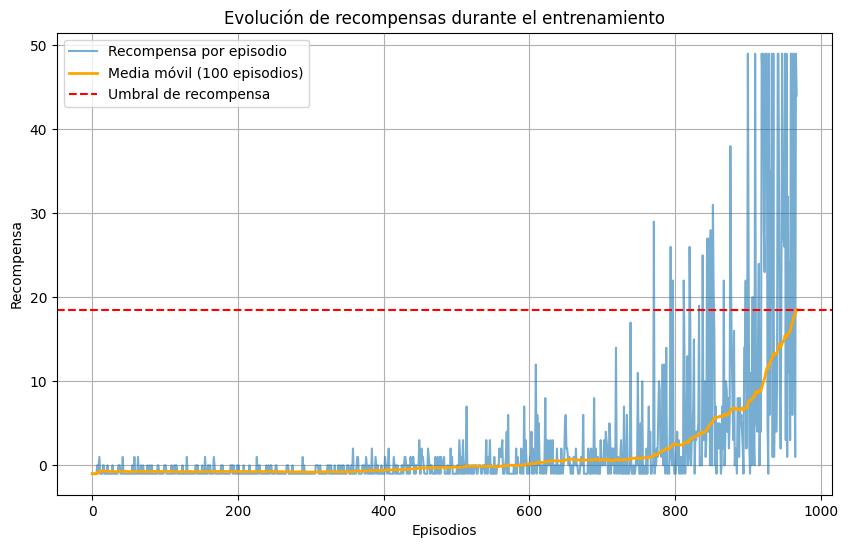

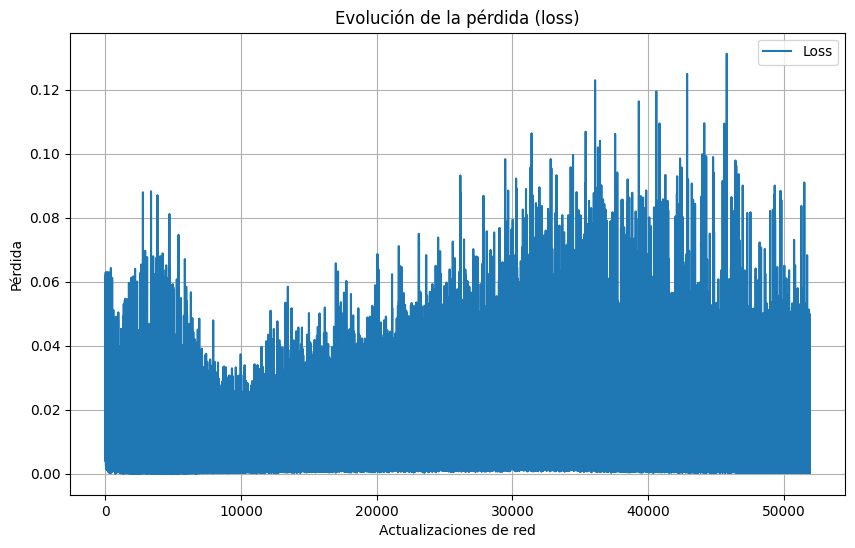

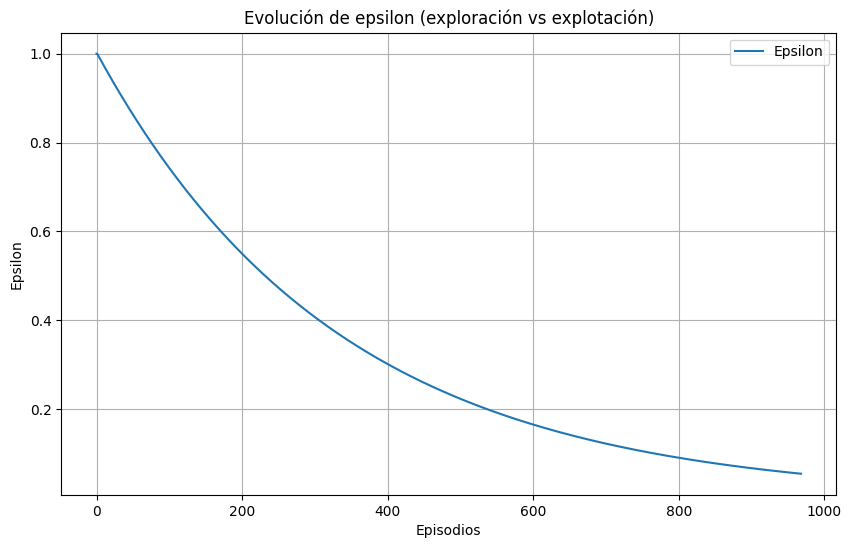

In [27]:
#TODO: Mostrar gráficas
plot_rewards(agent.episode_rewards, agent.mean_rewards_100, reward_goal)
plot_loss(agent.update_loss)
plot_epsilon(agent.epsilon_history)

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
El entrenamiento resulta muy similar a los ejercicios anteriores, siguiendo las mismas distribuciones de evolución de la pérdida y de la recompensa media por episodio, convergiendo cuando la recompensa por episodio alcanza 49.0 (y cuya media móvil es 18.5 el límite establecido). Esto indica que no hay mucha diferencia en la política alcanzada entre este modelo y los anteriores.
</div>


### 4.2 Test del agente en Pong

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio 4.4(0.75 ptos):</strong> Cargar el modelo entrenado y evaluar su comportamiento en el entorno <code>Pong-v0</code>.

Para ello, realiza las siguientes tareas en este orden:

<ol>
  <li><strong>Visualización de una partida:</strong> Ejecuta una partida completa del agente entrenado en el entorno Pong y muestra por pantalla el resultado final (por ejemplo, puntuación total o número de puntos ganados).<br></li>

  <li><strong>Evaluación cuantitativa:</strong> Ejecuta el agente durante <strong>20 partidas consecutivas</strong> sin renderizar y calcula las métricas de rendimiento:</li>
  <ul>
    <li>Recompensa media obtenida en las 20 partidas &rarr; almacénala en la variable <code>mean_reward_dqn_test</code>.</li>
  </ul>

  <li><strong>Gráfico de resultados:</strong> Representa un gráfico con la suma de recompensas obtenidas en las 20 partidas de test, incluyendo una línea horizontal que indique el umbral de recompensa objetivo (por ejemplo, <code>REWARD_THRESHOLD = 18</code>).</li>

  <li><strong>Análisis final:</strong> Comenta los resultados obtenidos:
    <ul>
      <li>¿Ha alcanzado el agente un rendimiento estable y superior al umbral de recompensa?</li>
      <li>¿Muestra el comportamiento esperado en Pong?</li>
<li>¿El modelo mejora al anterior? Justifica la respuesta con base teórica.</li>
    </ul>
  </li>
</ol>
</div>




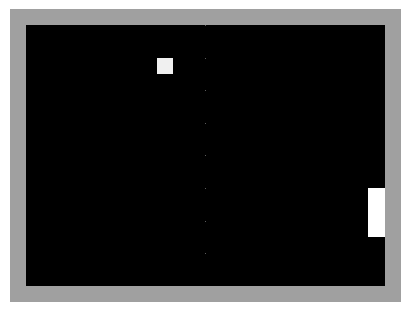

Recompensa total: 49.0
Recompensa media en test: 49.00


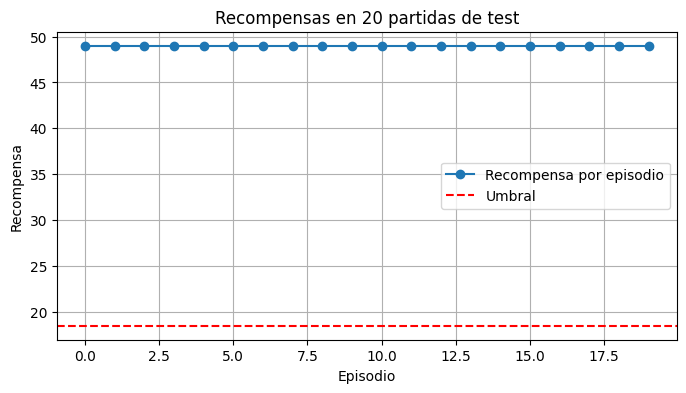

In [28]:
#TODO: Test del agente
env = gym.make("SimplePong-v0", render_mode="rgb_array",
               width=24, height=18, paddle_size=4, rgb_scale=18, max_steps=2000)

obs, _ = env.reset()

fig, ax = plt.subplots(figsize=(5.5, 3.8))
frame = env.render()
im = ax.imshow(frame, interpolation="nearest")
ax.axis("off")
disp = display(fig, display_id=True)

total_r = 0.0

terminated = False
truncated = False

while not terminated and not truncated:
    
    action = agent.main_network.get_action(obs, epsilon=0.0)

    obs, reward, terminated, truncated, _ = env.step(action)
    total_r += reward

    frame = env.render()
    im.set_data(frame)
    fig.canvas.draw_idle()
    disp.update(fig)
    time.sleep(0.001)

print("Recompensa total:", round(total_r, 2))
env.close()
plt.close(fig)


#TODO: Evaluación y gráfico de los resultados
env = gym.make("SimplePong-v0")
num_test_episodes = 20
episode_rewards = []

for ep in range(num_test_episodes):
    obs, _ = env.reset()
    terminated, truncated = False, False
    total_reward = 0.0

    while not (terminated or truncated):
        # Acción greedy (epsilon=0)
        action = agent.main_network.get_action(obs, epsilon=0.0)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

    episode_rewards.append(total_reward)

# Recompensa media
mean_reward_dqn_test = np.mean(episode_rewards)
print(f"Recompensa media en test: {mean_reward_dqn_test:.2f}")

# Gráfico
plt.figure(figsize=(8, 4))
plt.plot(episode_rewards, marker='o', label="Recompensa por episodio")
plt.axhline(reward_goal, color='r', linestyle='--', label='Umbral')
plt.title(f"Recompensas en {num_test_episodes} partidas de test")
plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
Vemos que, así como en los ejercicios anteriores, también se llega a una política muy consistente cercana a lo óptimo. Aunque que los resultados sean muy parecidos me hace sospechar de un error en el código, no he encontrado nada, y viendo que las medias de entrenamiento cambian para los distintos modelos, sigue siendo posible que los tres modelos convergan en una misma política.
</div>

<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Fuentes Ejercicio 4:</strong>
<br><br>
Ejercicios anteriores. <br>
https://towardsdatascience.com/dueling-double-deep-q-learning-using-tensorflow-2-x-7bbbcec06a2a/ <br>
https://github.com/fschur/DDQN-with-PyTorch-for-OpenAI-Gym <br>
</div>


## 5 Comparación de los resultados (1 pto)

Ahora vamos a comparar los resultados. Si has seguido todas las indicaciones, habrás almacenado métricas bastante interesantes que te permitirán interpretar los resultados obtenidos.

In [29]:
def interpretar_resultados(results, nombre_agente, tiempo_entrenamiento):
    episode_rewards, mean_rewards_100, episodes_train_dqn, epsilon_history, update_loss = results
    
    # Media de recompensas de entrenamiento
    mean_reward_train = np.mean(episode_rewards)
    
    # Última media móvil de 100 episodios
    mean_reward_test = mean_rewards_100[-1] if len(mean_rewards_100) > 0 else None
    
    return [nombre_agente, mean_reward_train, mean_reward_test, tiempo_entrenamiento]

# Define los datos de la tabla
data = [
    interpretar_resultados(results_dqn, "DQN", time_dqn),
    interpretar_resultados(results_dueling, "Dueling DQN", time_dueling),
    interpretar_resultados(results_ddqn, "Double DQN", time_ddqn),
]

# Define los encabezados de la tabla
headers = ["Agente", "Media Reward de Entrenamiento", "Media test con 100 Partidas Aleatorias" , "Tiempo entrenamiento."]

# Imprime la tabla
table = tabulate(data, headers, tablefmt="pipe")
print(table)

| Agente      |   Media Reward de Entrenamiento |   Media test con 100 Partidas Aleatorias |   Tiempo entrenamiento. |
|:------------|--------------------------------:|-----------------------------------------:|------------------------:|
| DQN         |                         2.80841 |                                    18.66 |                 254.062 |
| Dueling DQN |                         2.61086 |                                    18.73 |                 263.312 |
| Double DQN  |                         2.39876 |                                    18.56 |                 202.803 |


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio (1 pto):</strong>

Comentar los resultados obtenidos. ¿qué agente ha logrado un mejor rendimiento?
Si el entorno Pong no transfiriera al agente la información sobre la posición o el movimiento de la pelota, ¿cómo podríamos obtener o estimar esa información? ¿Modificaria los resultados?
    
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
Aunque dueling DQN parece ser la que obtiene mejores resultados en el test de 100 partidas, los tres modelos obtienen resultados muy parecidos, lo que puede ser debido a que se alcance una misma política cercana a la óptima teniendo en cuenta los resultados de graficar la media de 20 partidas.
En cuanto al tiempo de entrenamiento, si que puede verse una clara diferencia entre double dqn y los otros modelos, siendo este casi un minuto más rápido, y manteniendo la eficiencia del entrenamiento. En conclusión dueling dqn encuentra una mejor política, pero double dqn tiene un tiempo de entrenamiento significativamente menor. 
</div>


<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Fuentes Ejercicio 5:</strong>
<br><br>
Sin fuentes adicionales.
</div>